# PREPARACIÓN PARA IMPUTACIÓN DE VARIABLES

Se realiza una preparación previa mediante la extracción de la información de la base de datos en formato CSV y la importación de todas las librerías necesarias para el desarrollo de este notebook de imputación de datos.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from scipy import stats
import warnings
from pathlib import Path
from sklearn.preprocessing import OrdinalEncoder
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

pd.set_option("display.max_columns", None)
bd = pd.read_csv("/content/energia_v1_processed.csv")

In [ ]:
bd = bd.dropna(subset=["perfil_energetico"]).reset_index(drop=True) # No considerar esto dentro de este documento, se pasara posteriormente a otro notebook

In [ ]:
print("="*80)
print("LIMPIEZA ESTRUCTURAL: ELIMINACIÓN DE FILAS COMPLETAMENTE VACÍAS") # No considerar esto dentro de este documento, se pasara posteriormente a otro notebook
print("="*80)

total_original = len(bd)

# Definimos las variables físicas y energéticas reales (excluyendo el ID de registro)
cols_variables_reales = [col for col in bd.columns if col != 'id_registro']

# Borramos únicamente las filas donde TODAS las variables reales sean NaN
bd = bd.dropna(subset=cols_variables_reales, how='all').reset_index(drop=True)

filas_borradas = total_original - len(bd)
print(f"Total de registros originales : {total_original:,}")
print(f"Filas 100% vacías eliminadas  : {filas_borradas:,}")
print(f"Total de registros limpios    : {len(bd):,}\n")

LIMPIEZA ESTRUCTURAL: ELIMINACIÓN DE FILAS COMPLETAMENTE VACÍAS
Total de registros originales : 96,421
Filas 100% vacías eliminadas  : 0
Total de registros limpios    : 96,421



In [ ]:
# ==========================================================
# SCRIPT DE CONTEO: Filas con tiene_aa = 0, horas_aa = 0, unidad_aa = 0
# DataFrame: bd
# ==========================================================

print("="*80)
print("AUDITORÍA DE REGISTROS COMPLETAMENTE NULOS / CERO EN AIRE ACONDICIONADO")
print("="*80)

# Columnas estándar utilizadas en el dataset
col_tiene = "tiene_aire_acondicionado"
col_horas = "horas_uso_aa_dia"
col_unidades = "cantidad_unidades_aa"

cols_requeridas = [col_tiene, col_horas, col_unidades]

if all(c in bd.columns for c in cols_requeridas):
    # Condición exacta: los tres campos deben ser igual a 0
    mask = (
        (bd[col_tiene] == 0) &
        (bd[col_horas] == 0) &
        (bd[col_unidades] == 0)
    ).fillna(False)

    conteo = int(mask.sum())
    total_filas = len(bd)
    porcentaje = (conteo / total_filas) * 100 if total_filas > 0 else 0

    print(f"\nResultados del conteo:")
    print(f"• Filas que cumplen la condición (0 en los tres campos): {conteo:,}")
    print(f"• Total de filas en el DataFrame: {total_filas:,}")
    print(f"• Representa el {porcentaje:.2f}% del total de la base de datos.")
else:
    print("⚠️ Error: Una o más columnas requeridas no existen en el DataFrame 'bd'.")
    print(f"Columnas buscadas: {cols_requeridas}")
    print(f"Columnas disponibles en 'bd': {list(bd.columns)}")

AUDITORÍA DE REGISTROS COMPLETAMENTE NULOS / CERO EN AIRE ACONDICIONADO

Resultados del conteo:
• Filas que cumplen la condición (0 en los tres campos): 30,084
• Total de filas en el DataFrame: 96,421
• Representa el 31.20% del total de la base de datos.


# FASE 1: ANÁLISIS DE MECANISMOS DE AUSENCIA

En esta fase se usarán los gráficos de missingno y tablas extra que representen cómo se distribuyen y aparecen los nulos a lo largo de toda la distribución. Esto permitirá tener una visión general de los valores nulos para su posterior imputación y corrección en fases posteriores.

Visualización: Frecuencia de Valores Faltantes (msno.bar)



**Análisis:**
- **Resumen:** Este gráfico cuantifica la cantidad de datos disponibles por variable.

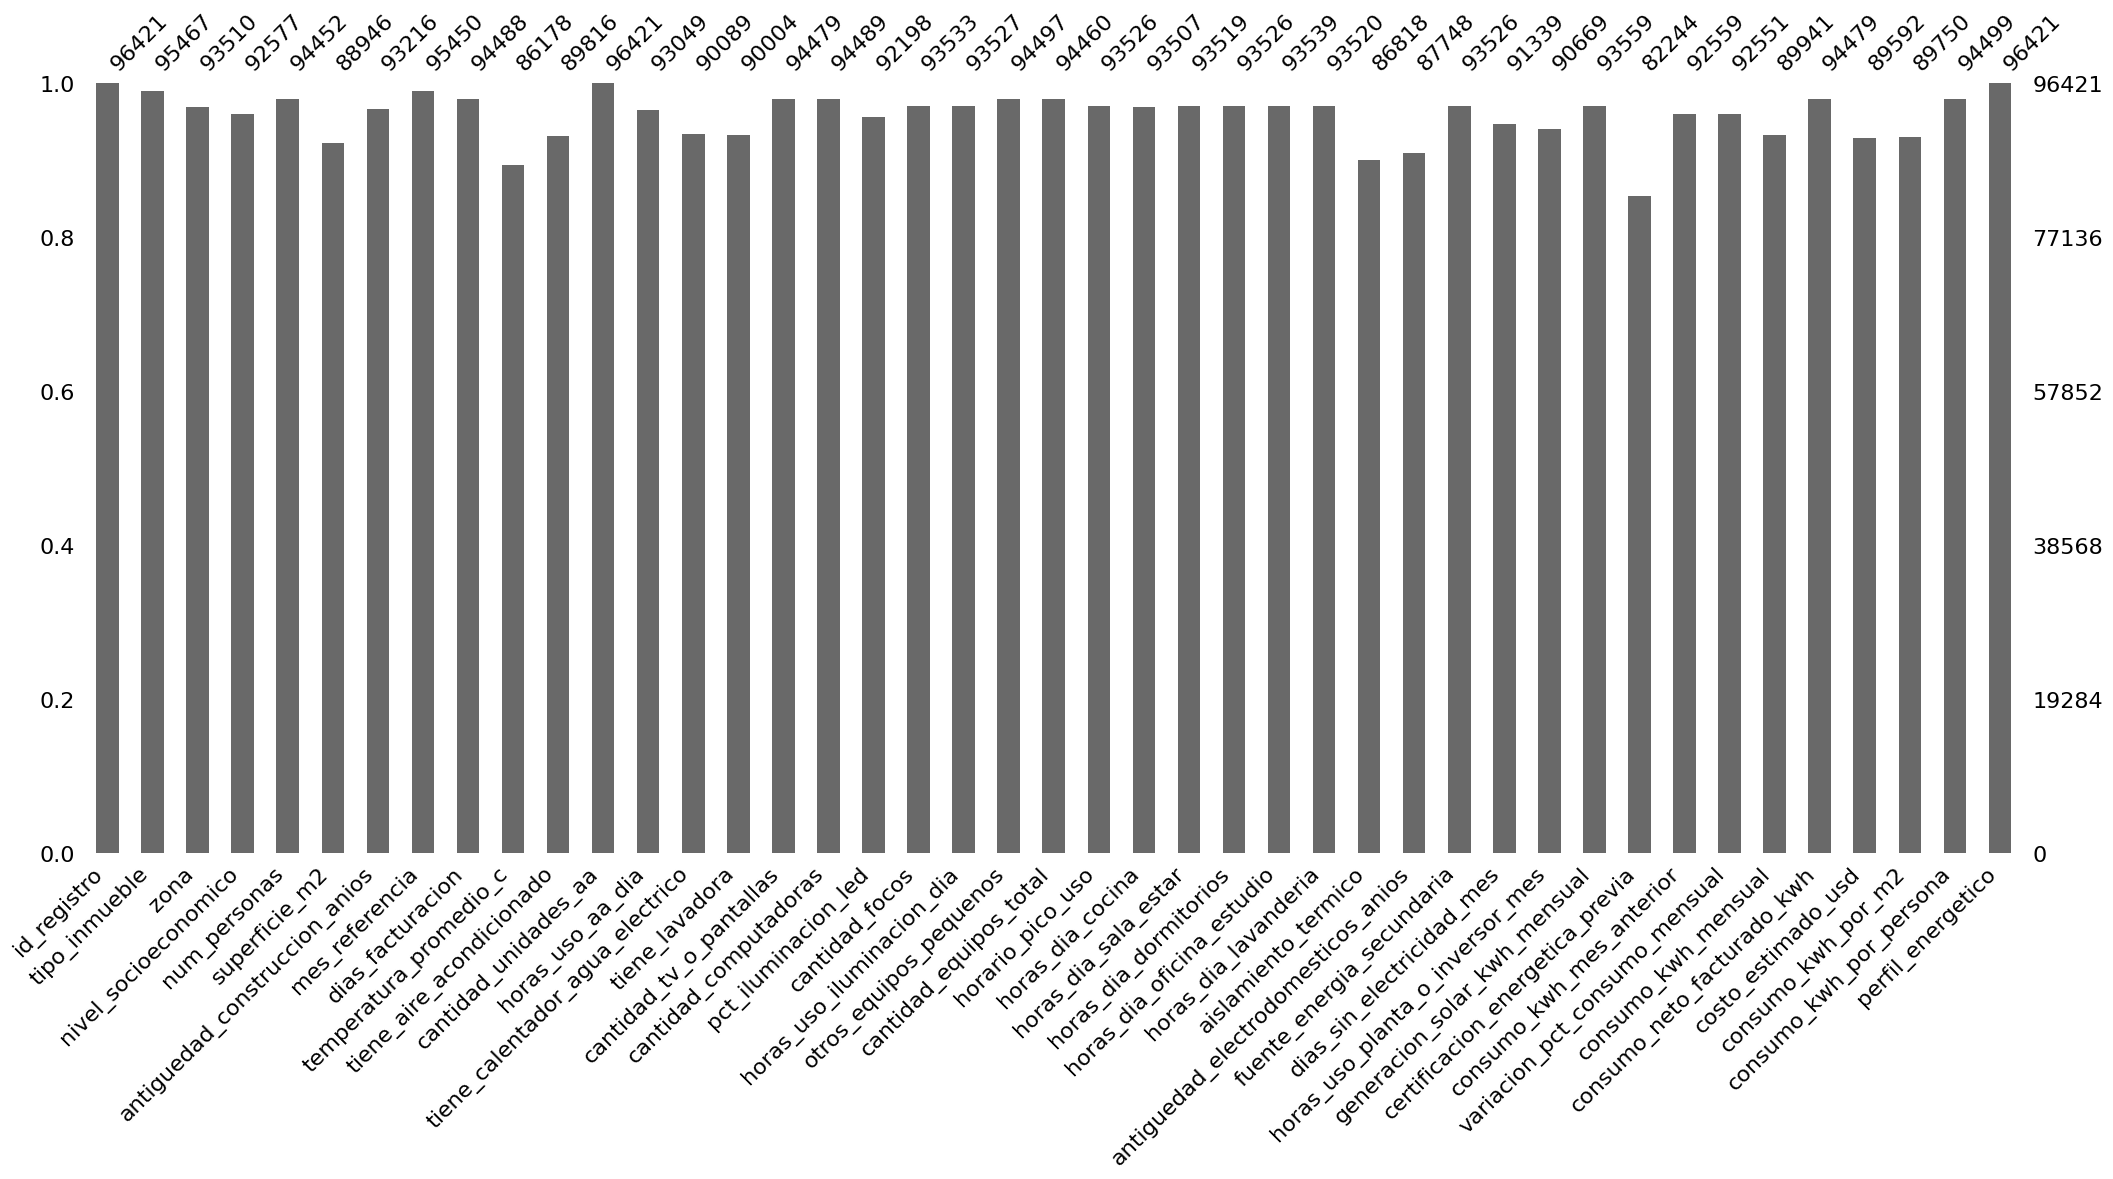

In [ ]:

# 3. Gráfico de barras: Para ver el conteo limpio
msno.bar(bd)

plt.show()

Mediante el gráfico de barras de Missingno también se pueden corroborar los resultados obtenidos previamente. De forma general, se observa que la mayoría de las variables presentan proporciones de completitud cercanas al 100 %, lo que indica que contienen pocos valores nulos.

Con la tabla de proporción y cantidad de valores nulos se puede observar que la mayoría de las variables presentan un porcentaje superior al 3 % de valores correspondientes a `np.nan`. La variable con mayor cantidad de valores nulos es `certificacion_energetica_previa`, por lo que puede convertirse en una prioridad al momento de determinar el posible **mecanismo de ausencia de datos**.


Visualización: Matriz de Completitud (msno.matrix)



**Análisis:**
- **Densidad:** El gráfico permite identificar visualmente áreas donde los datos faltan de manera concentrada.
- **Patrones:** Si observamos líneas horizontales vacías o bloques de nulos, sugiere que la ausencia de información podría estar correlacionada con subgrupos específicos de inmuebles o condiciones de recolección de datos.

<Axes: >

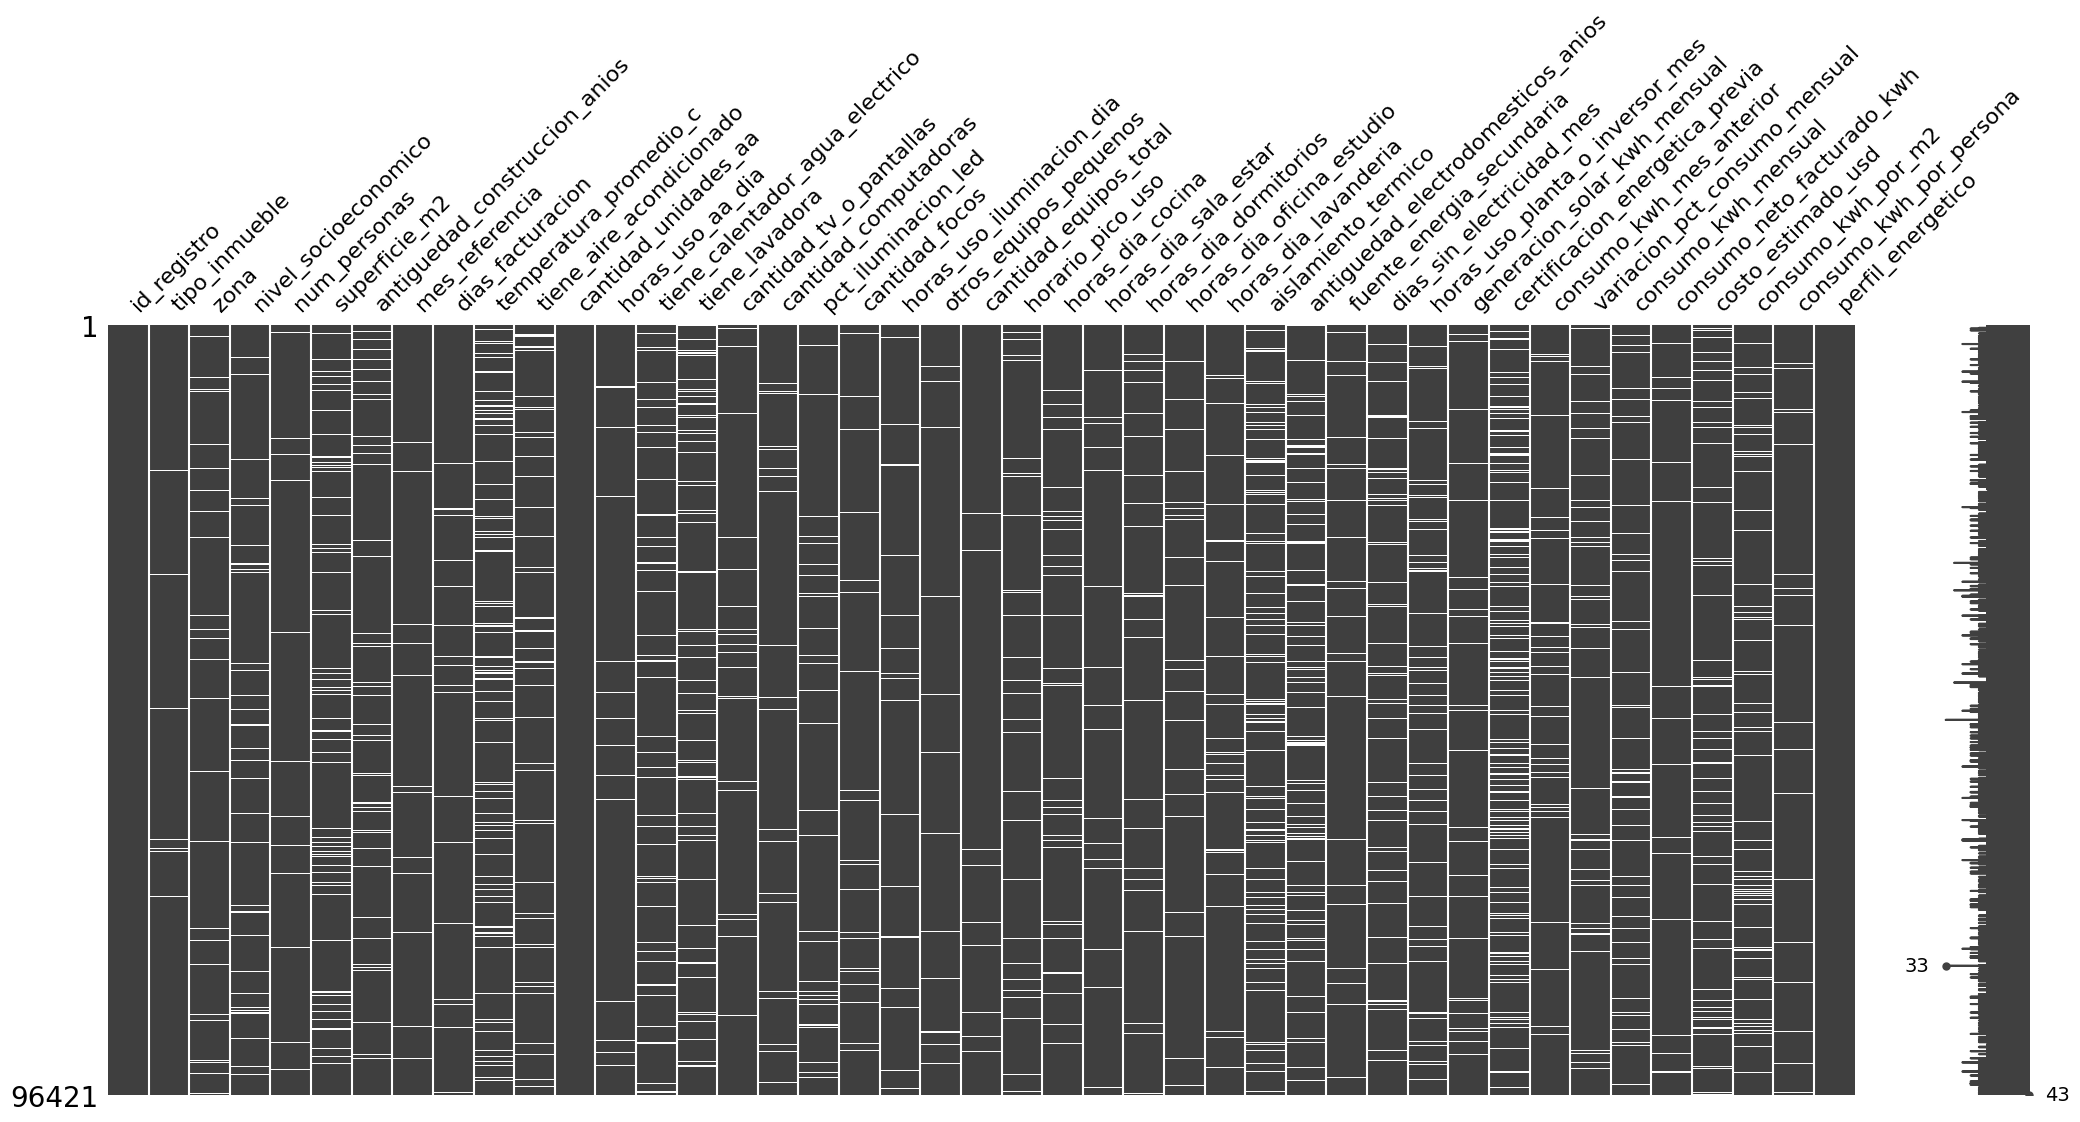

In [ ]:
# 1. Matriz de nulos: Ideal para ver la dispersión global
msno.matrix(bd)

Respecto a la matriz de completitud, se observa una baja presencia de datos faltantes en el conjunto de datos. La distribución de las filas blancas confirma la información presentada previamente en la tabla de valores nulos, ya que permite identificar visualmente las variables con una mayor proporción de valores ausentes, como tiene_lavadora.

Por otro lado, también destaca una línea continua en el resumen ubicado al extremo derecho del gráfico, lo que sugiere la existencia de una o más observaciones con una proporción considerable de variables faltantes. Este patrón indica que dichas observaciones presentan un nivel de completitud significativamente inferior al del resto del conjunto de datos.

Este comportamiento podría deberse a las etapas previas de limpieza del conjunto de datos, durante las cuales alguna condición de análisis univariado o multivariado pudo haber ocasionado la eliminación selectiva de valores en esas observaciones. No obstante, esta hipótesis deberá verificarse mediante el análisis del mecanismo de ausencia de datos, con el fin de determinar si dicho patrón corresponde a un proceso sistemático o aleatorio.

Visualización: Dendrograma de Correlación (msno.dendrogram)


**Análisis:**
- **Interpretación:** Las variables que se agrupan (distancia cercana a cero) tienen una correlación fuerte en la ausencia de sus datos.
- **Mecanismo de datos:** Si dos variables se agrupan estrechamente, es un indicador fuerte de que el mecanismo de falta de datos es **MAR (Missing at Random)**, ya que la ausencia de información en una variable está condicionada por la otra. Esto es vital para justificar tu estrategia de imputación.

<Axes: >

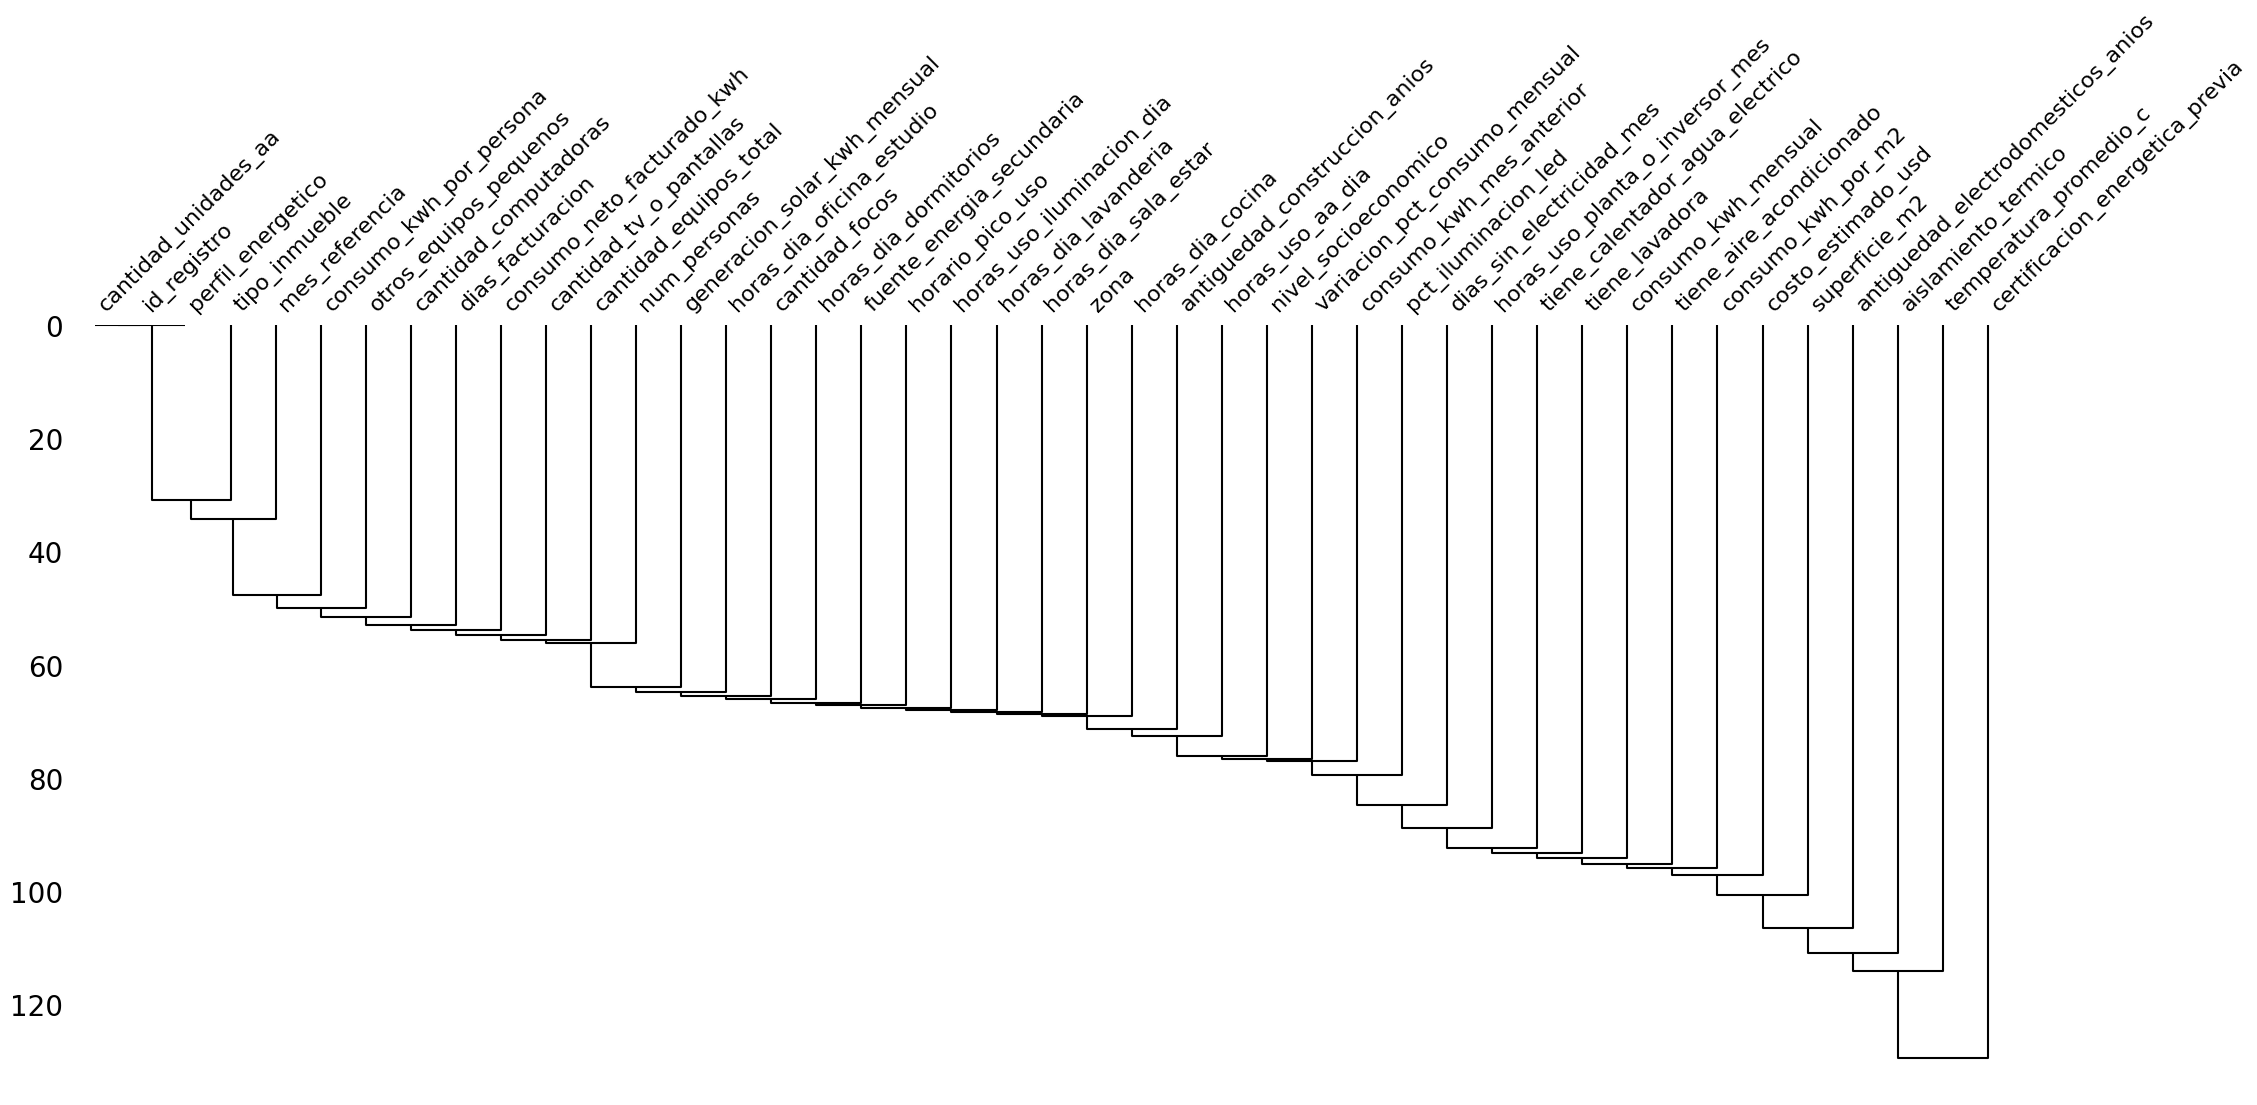

In [ ]:
# 2. Dendrograma: Vital para detectar mecanismos
msno.dendrogram(bd)

El dendrograma revela que las variables cantidad_unidades_aa e id_registro presentan un patrón de completitud similar. No obstante, esta asociación carece de relevancia analítica, ya que id_registro corresponde a un identificador único y no constituye una variable explicativa. Sin embargo, este resultado corrobora la información presentada previamente en la tabla de valores nulos, al evidenciar que la columna id_registro también contiene un reducido número de valores faltantes.

Visualización: Mapa de Calor de Correlación de Nulos (msno.heatmap)

**Análisis:**
- **Interpretación:** Este mapa de calor mide la correlación de nulidad entre pares de columnas. El coeficiente varía de -1 a 1, indicando qué tan fuertemente la presencia o ausencia de un valor en una variable afecta a otra.

<Axes: >

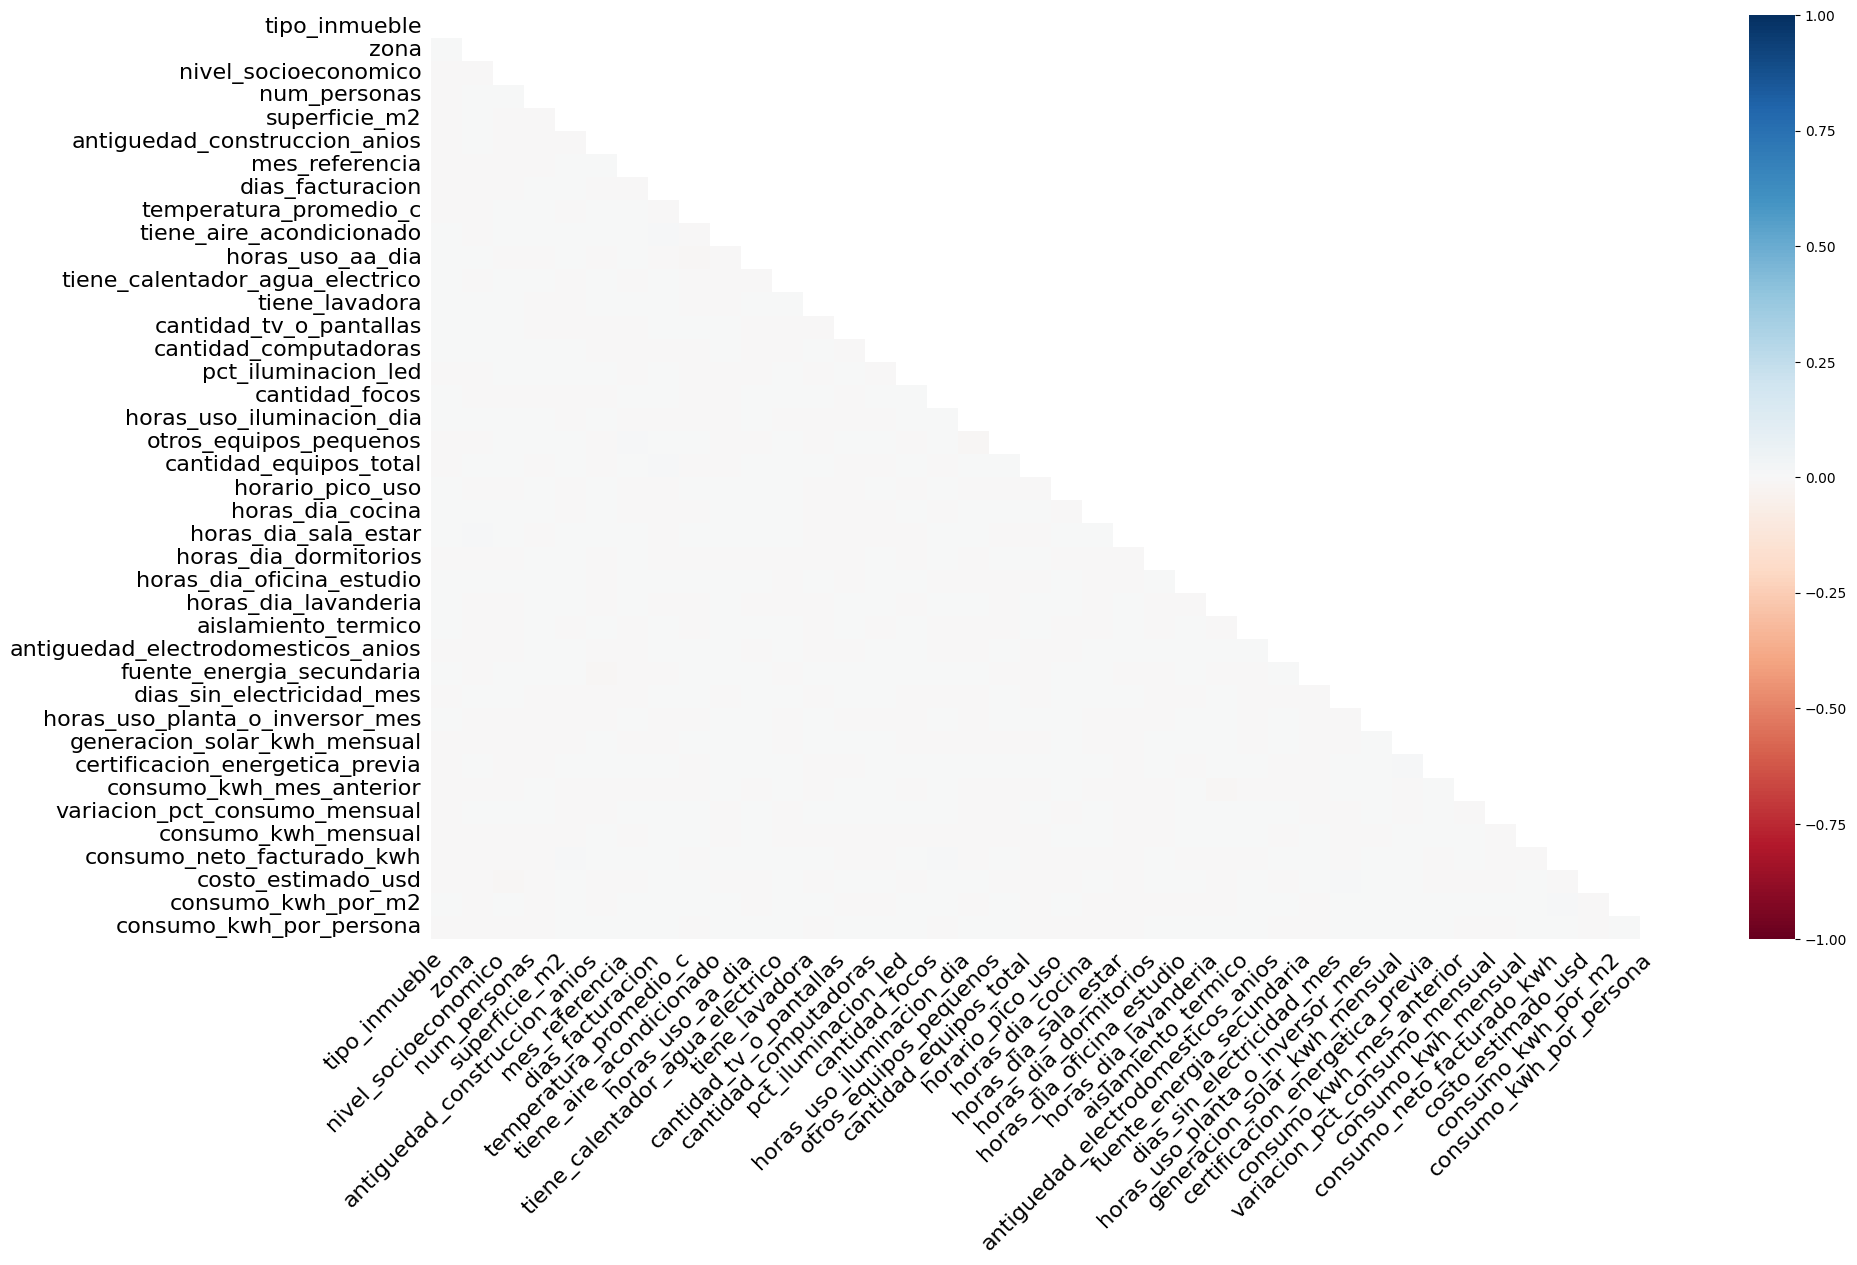

In [ ]:

msno.heatmap(bd)

Al analizar el mapa de calor de correlación de valores nulos, se observa que no existen relaciones significativas entre la ausencia de datos de las distintas variables. La única correlación que destaca corresponde a horas_uso_aa_dia y cantidad_unidades_aa; sin embargo, esta presenta una intensidad moderada, con un coeficiente de aproximadamente 0.5.

Este resultado sugiere que existe una asociación moderada entre la ausencia de datos de ambas variables, es decir, que en una proporción de los casos la ausencia de valores en horas_uso_aa_dia coincide con la ausencia de valores en cantidad_unidades_aa. No obstante, la magnitud de esta correlación no es lo suficientemente alta como para afirmar una dependencia fuerte entre ambas variables, por lo que será necesario realizar análisis adicionales para determinar si dicho patrón responde a un mecanismo específico de ausencia de datos.

In [ ]:
# ==========================================================
# ANÁLISIS DE VALORES FALTANTES
# DataFrame: bd
# ==========================================================

print("="*80)
print("ANÁLISIS DE VALORES FALTANTES")
print("="*80)

# ==========================================================
# TABLA 1
# Nulos por variable
# ==========================================================

print("\n[1] Valores faltantes por variable\n")

total_registros = len(bd)

reporte_nulos = pd.DataFrame({

    "Variable": bd.columns,

    "Cantidad de nulos": [
        int(bd[col].isna().sum())
        for col in bd.columns
    ],

    "Porcentaje (%)": [
        (bd[col].isna().sum() / total_registros) * 100
        for col in bd.columns
    ]

})

reporte_nulos["Porcentaje (%)"] = (
    reporte_nulos["Porcentaje (%)"]
    .round(2)
)

display(

    reporte_nulos.sort_values(
        by="Cantidad de nulos",
        ascending=False
    ).reset_index(drop=True)

)

# ==========================================================
# TABLA 2
# Resumen general del dataset
# ==========================================================

print("\n[2] Resumen general del dataset\n")

total_celdas = bd.shape[0] * bd.shape[1]

total_nulos = int(bd.isna().sum().sum())

porcentaje_nulos = (
    total_nulos / total_celdas
) * 100

resumen = pd.DataFrame({

    "Total de registros": [bd.shape[0]],

    "Total de variables": [bd.shape[1]],

    "Total de celdas": [total_celdas],

    "Cantidad total de nulos": [total_nulos],

    "Porcentaje total de nulos (%)": [
        round(porcentaje_nulos, 2)
    ]

})

display(resumen)

# ==========================================================
# RESUMEN
# ==========================================================

print("\n"+"="*80)
print("RESUMEN")
print("="*80)

print(f"Variables analizadas          : {bd.shape[1]}")
print(f"Registros analizados          : {bd.shape[0]}")
print(f"Valores faltantes totales     : {total_nulos}")
print(f"Porcentaje de nulos del dataset: {porcentaje_nulos:.2f}%")

print("\nProceso finalizado correctamente.")

ANÁLISIS DE VALORES FALTANTES

[1] Valores faltantes por variable



,Variable,Cantidad de nulos,Porcentaje (%)
0,certificacion_energetica_previa,14177,14.70
1,temperatura_promedio_c,10243,10.62
2,aislamiento_termico,9603,9.96
3,antiguedad_electrodomesticos_anios,8673,8.99
4,superficie_m2,7475,7.75
5,costo_estimado_usd,6829,7.08
6,consumo_kwh_por_m2,6671,6.92
7,tiene_aire_acondicionado,6605,6.85
8,consumo_kwh_mensual,6480,6.72
9,tiene_lavadora,6417,6.66



[2] Resumen general del dataset



,Total de registros,Total de variables,Total de celdas,Cantidad total de nulos,Porcentaje total de nulos (%)
0,96421,43,4146103,172004,4.15



RESUMEN
Variables analizadas          : 43
Registros analizados          : 96421
Valores faltantes totales     : 172004
Porcentaje de nulos del dataset: 4.15%

Proceso finalizado correctamente.


In [ ]:
# ==========================================================
# CLASIFICACIÓN DE VARIABLES SEGÚN EL DICCIONARIO DE DATOS
# ==========================================================

clasificacion = {
    "id_registro": "Identificador",

    "tipo_inmueble": "Categórica Nominal",
    "zona": "Categórica Nominal",
    "nivel_socioeconomico": "Categórica Ordinal",

    "num_personas": "Numérica Discreta",
    "superficie_m2": "Numérica Continua",
    "antiguedad_construccion_anios": "Numérica Discreta",

    "mes_referencia": "Categórica Ordinal",

    "dias_facturacion": "Numérica Discreta",
    "temperatura_promedio_c": "Numérica Continua",

    "tiene_aire_acondicionado": "Binaria",
    "cantidad_unidades_aa": "Numérica Discreta",
    "horas_uso_aa_dia": "Numérica Continua",

    "tiene_calentador_agua_electrico": "Binaria",
    "tiene_lavadora": "Binaria",

    "cantidad_tv_o_pantallas": "Numérica Discreta",
    "cantidad_computadoras": "Numérica Discreta",

    "pct_iluminacion_led": "Numérica Continua",

    "cantidad_focos": "Numérica Discreta",

    "horas_uso_iluminacion_dia": "Numérica Continua",

    "otros_equipos_pequenos": "Numérica Discreta",
    "cantidad_equipos_total": "Numérica Discreta",

    "horario_pico_uso": "Categórica Ordinal",

    "horas_dia_cocina": "Numérica Continua",
    "horas_dia_sala_estar": "Numérica Continua",
    "horas_dia_dormitorios": "Numérica Continua",
    "horas_dia_oficina_estudio": "Numérica Continua",
    "horas_dia_lavanderia": "Numérica Continua",

    "aislamiento_termico": "Categórica Ordinal",

    "antiguedad_electrodomesticos_anios": "Numérica Continua",

    "fuente_energia_secundaria": "Categórica Nominal",

    "dias_sin_electricidad_mes": "Numérica Discreta",

    "horas_uso_planta_o_inversor_mes": "Numérica Continua",

    "generacion_solar_kwh_mensual": "Numérica Continua",

    "certificacion_energetica_previa": "Binaria",

    "consumo_kwh_mes_anterior": "Numérica Continua",

    "variacion_pct_consumo_mensual": "Numérica Continua",

    "consumo_kwh_mensual": "Numérica Continua",

    "consumo_neto_facturado_kwh": "Numérica Continua",

    "costo_estimado_usd": "Numérica Continua",

    "consumo_kwh_por_m2": "Numérica Continua",

    "consumo_kwh_por_persona": "Numérica Continua",

    "perfil_energetico": "Variable Objetivo (Categórica Ordinal)"
}

df_clasificacion = pd.DataFrame([clasificacion])

display(df_clasificacion)

,id_registro,tipo_inmueble,zona,nivel_socioeconomico,num_personas,superficie_m2,antiguedad_construccion_anios,mes_referencia,dias_facturacion,temperatura_promedio_c,tiene_aire_acondicionado,cantidad_unidades_aa,horas_uso_aa_dia,tiene_calentador_agua_electrico,tiene_lavadora,cantidad_tv_o_pantallas,cantidad_computadoras,pct_iluminacion_led,cantidad_focos,horas_uso_iluminacion_dia,otros_equipos_pequenos,cantidad_equipos_total,horario_pico_uso,horas_dia_cocina,horas_dia_sala_estar,horas_dia_dormitorios,horas_dia_oficina_estudio,horas_dia_lavanderia,aislamiento_termico,antiguedad_electrodomesticos_anios,fuente_energia_secundaria,dias_sin_electricidad_mes,horas_uso_planta_o_inversor_mes,generacion_solar_kwh_mensual,certificacion_energetica_previa,consumo_kwh_mes_anterior,variacion_pct_consumo_mensual,consumo_kwh_mensual,consumo_neto_facturado_kwh,costo_estimado_usd,consumo_kwh_por_m2,consumo_kwh_por_persona,perfil_energetico
0,Identificador,Categórica Nominal,Categórica Nominal,Categórica Ordinal,Numérica Discreta,Numérica Continua,Numérica Discreta,Categórica Ordinal,Numérica Discreta,Numérica Continua,Binaria,Numérica Discreta,Numérica Continua,Binaria,Binaria,Numérica Discreta,Numérica Discreta,Numérica Continua,Numérica Discreta,Numérica Continua,Numérica Discreta,Numérica Discreta,Categórica Ordinal,Numérica Continua,Numérica Continua,Numérica Continua,Numérica Continua,Numérica Continua,Categórica Ordinal,Numérica Continua,Categórica Nominal,Numérica Discreta,Numérica Continua,Numérica Continua,Binaria,Numérica Continua,Numérica Continua,Numérica Continua,Numérica Continua,Numérica Continua,Numérica Continua,Numérica Continua,Variable Objetivo (Categórica Ordinal)


# FASE 2: CORRECCIONES DETERMINÍSTICAS

Se hacen correcciones basadas en lógica y jerarquía entre las variables para evitar que entre información no útil al modelo durante su entrenamiento. Además, este proceso también ayuda a limpiar el dataset de relaciones que podrían distorsionar la imputación de datos en fases posteriores.

Las condiciones logicas usadas fueron:

## GRP_01 - Cantidad de dispositivos

* cantidad_equipos_total == NaN y cantidad_tv_o_pantallas != NaN y cantidad_computadoras != NaN y otros_equipos_pequenos != NaN -> cantidad_equipos_total = cantidad_tv_o_pantallas + cantidad_computadoras + otros_equipos_pequenos
* cantidad_equipos_total < (cantidad_tv_o_pantallas + cantidad_computadoras + otros_equipos_pequenos) y todos los componentes != NaN -> cantidad_equipos_total = cantidad_tv_o_pantallas + cantidad_computadoras + otros_equipos_pequenos

## GRP_02 - Aire acondicionado

* cantidad_unidades_aa > 0 o horas_uso_aa_dia > 0 -> tiene_aire_acondicionado = 1
* (tiene_aire_acondicionado == 1 o horas_uso_aa_dia > 0) y cantidad_unidades_aa == 0 -> cantidad_unidades_aa = NaN
* tiene_aire_acondicionado == 0 y (cantidad_unidades_aa == NaN o horas_uso_aa_dia == NaN) -> cantidad_unidades_aa = 0, horas_uso_aa_dia = 0

## GRP_03 - Iluminación

* cantidad_focos == 0 -> pct_iluminacion_led = 0, horas_uso_iluminacion_dia = 0
* cantidad_focos == 0 y (pct_iluminacion_led > 0 o horas_uso_iluminacion_dia > 0) -> cantidad_focos = NaN
* horas_uso_iluminacion_dia == 0 y cantidad_focos == NaN -> cantidad_focos = 0, pct_iluminacion_led = 0

## GRP_04 - Lavandería

* horas_dia_lavanderia > 0 y tiene_lavadora != 1 -> tiene_lavadora = 1
* tiene_lavadora == 0 y horas_dia_lavanderia == NaN -> horas_dia_lavanderia = 0
* horas_dia_lavanderia == 0 y tiene_lavadora == NaN -> tiene_lavadora = 0

## GRP_05 - Respaldo y Energía Solar

* generacion_solar_kwh_mensual > 0 y horas_uso_planta_o_inversor_mes == 0 y (fuente_energia_secundaria == "Ninguna" o fuente_energia_secundaria == NaN) -> fuente_energia_secundaria = "Panel Solar"
* horas_uso_planta_o_inversor_mes > 0 y fuente_energia_secundaria == "Ninguna" -> fuente_energia_secundaria = NaN
* fuente_energia_secundaria == "Ninguna" -> horas_uso_planta_o_inversor_mes = 0, generacion_solar_kwh_mensual = 0
* dias_sin_electricidad_mes == 0 y fuente_energia_secundaria != "Panel Solar" y horas_uso_planta_o_inversor_mes == NaN -> horas_uso_planta_o_inversor_mes = 0

## GRP_06 - Balance Eléctrico Mensual e Inventario

* consumo_kwh_mensual == 0 -> consumo_kwh_por_m2 = 0, consumo_kwh_por_persona = 0, costo_estimado_usd = 0, consumo_neto_facturado_kwh = 0
* consumo_kwh_mes_anterior == 0 y consumo_kwh_mensual == 0 -> variacion_pct_consumo_mensual = 0
* consumo_kwh_mes_anterior == 0 y consumo_kwh_mensual > 0 -> variacion_pct_consumo_mensual = 0
* generacion_solar_kwh_mensual > 0 y generacion_solar_kwh_mensual >= consumo_kwh_mensual -> consumo_neto_facturado_kwh = 0, costo_estimado_usd = 0


In [ ]:
print("="*80)
print("CORRECCIONES DETERMINÍSTICAS")
print("="*80)

reporte = []

# ==========================================================
# CORRECCIONES DETERMINÍSTICAS PREVIAS A LA IMPUTACIÓN
# DataFrame: bd | Grupo: GRP_01 (Cantidad de dispositivos)
# ==========================================================

# ==========================================================
# REGLA 1
# Rescate de Total Vacío: Si el total es NaN y los 3 componentes existen -> Suma de partes
# ==========================================================

if all(c in bd.columns for c in [
    "cantidad_tv_o_pantallas",
    "cantidad_computadoras",
    "otros_equipos_pequenos",
    "cantidad_equipos_total"
]):

    cols_comp = ["cantidad_tv_o_pantallas", "cantidad_computadoras", "otros_equipos_pequenos"]

    # Condición estricta: Todas las variables de componentes deben ser diferentes de null
    comp_completos = bd[cols_comp].notna().all(axis=1)

    suma_comp = bd[cols_comp].sum(axis=1)

    # Captura las filas donde el total está vacío PERO tenemos el desglose completo
    mask = (bd["cantidad_equipos_total"].isna() & comp_completos).fillna(False)

    n = int(mask.sum())

    if n > 0:
        bd.loc[mask, "cantidad_equipos_total"] = suma_comp[mask]

    reporte.append({
        "Regla": "Total vacio (NaN) con componentes completos → suma de dispositivos",
        "Correcciones": n
    })

# ==========================================================
# REGLA 2
# Blindaje Físico de Inventario: Si el total < suma de partes (sin nulos) -> Elevar a la suma
# ==========================================================

if all(c in bd.columns for c in [
    "cantidad_tv_o_pantallas",
    "cantidad_computadoras",
    "otros_equipos_pequenos",
    "cantidad_equipos_total"
]):

    cols_comp = ["cantidad_tv_o_pantallas", "cantidad_computadoras", "otros_equipos_pequenos"]

    # Condición estricta: Todas las variables de componentes deben ser diferentes de null
    comp_completos = bd[cols_comp].notna().all(axis=1)

    suma_comp = bd[cols_comp].sum(axis=1)

    # Captura imposibilidades físicas SOLO si el total existe Y no falta ningún componente
    mask = (
        (bd["cantidad_equipos_total"] < suma_comp)
        &
        (bd["cantidad_equipos_total"].notna())
        &
        comp_completos
    ).fillna(False)

    n = int(mask.sum())

    if n > 0:
        bd.loc[mask, "cantidad_equipos_total"] = suma_comp[mask]

    reporte.append({
        "Regla": "Total < Suma dispositivos (sin nulos) → ajustar a la suma",
        "Correcciones": n
    })

# ==========================================================
# REPORTE
# ==========================================================

print("\nResumen de las correcciones\n")

df_reporte = pd.DataFrame(reporte)

display(df_reporte)

print()
print(f"Total de reglas aplicadas : {len(df_reporte)}")
print(f"Total de correcciones     : {df_reporte['Correcciones'].sum()}")
print("\nProceso finalizado correctamente.")

CORRECCIONES DETERMINÍSTICAS

Resumen de las correcciones



,Regla,Correcciones
0,Total vacio (NaN) con componentes completos → ...,1860
1,Total < Suma dispositivos (sin nulos) → ajusta...,295



Total de reglas aplicadas : 2
Total de correcciones     : 2155

Proceso finalizado correctamente.


In [ ]:
# ==========================================================
# CORRECCIONES DETERMINÍSTICAS PREVIAS A LA IMPUTACIÓN
# DataFrame: bd | Grupo: GRP_02 (Aire acondicionado)
# ==========================================================

reporte = []

# ==========================================================
# REGLA 1
# Evidencia Positiva: Si hay equipos O hay horas -> tiene AA = 1
# ==========================================================

if all(c in bd.columns for c in [
    "tiene_aire_acondicionado",
    "cantidad_unidades_aa",
    "horas_uso_aa_dia"
]):

    mask = (
        (bd["cantidad_unidades_aa"] > 0)
        |
        (bd["horas_uso_aa_dia"] > 0)
    ).fillna(False)

    n = int(mask.sum())

    if n > 0:
        bd.loc[mask, "tiene_aire_acondicionado"] = 1.0

    reporte.append({
        "Regla": "Evidencia > 0 (Equipos u Horas) → tiene_aa = 1",
        "Correcciones": n
    })

# ==========================================================
# REGLA 2
# Corrección de Inventario: Si tiene AA = 1 O Horas > 0, con Equipos == 0 -> Equipos = NaN
# ==========================================================

if all(c in bd.columns for c in [
    "tiene_aire_acondicionado",
    "cantidad_unidades_aa",
    "horas_uso_aa_dia"
]):

    mask = (
        (
            (bd["tiene_aire_acondicionado"] == 1)
            |
            (bd["horas_uso_aa_dia"] > 0)
        )
        &
        (bd["cantidad_unidades_aa"] == 0)
    ).fillna(False)

    n = int(mask.sum())

    if n > 0:
        bd.loc[mask, "cantidad_unidades_aa"] = np.nan

    reporte.append({
        "Regla": "Tiene AA=1 o Horas>0 con Equipos=0 → equipos = NaN",
        "Correcciones": n
    })

# ==========================================================
# REGLA 3 (CIERRE DE NEGACIÓN EXPLÍCITA)
# Si declaró NO tener AA (booleano == 0) -> Equipos = 0 y Horas = 0
# ==========================================================

if all(c in bd.columns for c in [
    "tiene_aire_acondicionado",
    "cantidad_unidades_aa",
    "horas_uso_aa_dia"
]):

    mask = (
        (bd["tiene_aire_acondicionado"] == 0)
        &
        (bd["cantidad_unidades_aa"].isna() | bd["horas_uso_aa_dia"].isna())
    ).fillna(False)

    n = int(mask.sum())

    if n > 0:
        bd.loc[mask, "cantidad_unidades_aa"] = 0.0
        bd.loc[mask, "horas_uso_aa_dia"] = 0.0

    reporte.append({
        "Regla": "Sin AA (booleano=0) → equipos = 0, horas = 0",
        "Correcciones": n
    })

# ==========================================================
# REPORTE
# ==========================================================

print("\nResumen de las correcciones\n")

df_reporte = pd.DataFrame(reporte)

display(df_reporte)

print()
print(f"Total de reglas aplicadas : {len(df_reporte)}")
print(f"Total de correcciones     : {df_reporte['Correcciones'].sum()}")
print("\nProceso finalizado correctamente.")


Resumen de las correcciones



,Regla,Correcciones
0,Evidencia > 0 (Equipos u Horas) → tiene_aa = 1,63619
1,Tiene AA=1 o Horas>0 con Equipos=0 → equipos =...,328
2,"Sin AA (booleano=0) → equipos = 0, horas = 0",1107



Total de reglas aplicadas : 3
Total de correcciones     : 65054

Proceso finalizado correctamente.


In [ ]:
# ==========================================================
# CORRECCIONES DETERMINÍSTICAS PREVIAS A LA IMPUTACIÓN
# DataFrame: bd | Grupo: GRP_03 (Iluminación)
# ==========================================================

print("="*80)
print("CORRECCIONES DETERMINÍSTICAS - ILUMINACIÓN")
print("="*80)

reporte = []

# ==========================================================
# REGLA 1 (Antes Regla 2)
# Evidencia Positiva de Focos: Si hay % LED u horas -> focos > 0
# ==========================================================
# Si el encuestador registró 100% LED o 5 horas de uso, pero anotó 0 focos
# o lo dejó en NaN, se corrige el 0 a NaN para que MICE impute un número
# positivo coherente sin perder la varianza del consumo.

if all(c in bd.columns for c in [
    "cantidad_focos",
    "pct_iluminacion_led",
    "horas_uso_iluminacion_dia"
]):

    mask = (
        (bd["cantidad_focos"] == 0)
        &
        (
            (bd["pct_iluminacion_led"] > 0)
            |
            (bd["horas_uso_iluminacion_dia"] > 0)
        )
    ).fillna(False)

    n = int(mask.sum())

    if n > 0:
        # Se asigna NaN en lugar de 1.0 para que la imputación multivariada
        # estime la cantidad real según los m2 y el consumo eléctrico del hogar.
        bd.loc[mask, "cantidad_focos"] = np.nan

    reporte.append({
        "Regla": "Evidencia > 0 (% LED u Horas) con Focos == 0 → Focos a NaN",
        "Correcciones": n
    })

# ==========================================================
# REGLA 2 (Antes Regla 1)
# Jerarquía de Inventario: Si cantidad_focos == 0 -> todo a 0
# ==========================================================
# El inventario físico manda. Si la casa tiene genuinamente 0 focos, es
# matemáticamente imposible que tenga un porcentaje LED o registre horas de uso.

if all(c in bd.columns for c in [
    "cantidad_focos",
    "pct_iluminacion_led",
    "horas_uso_iluminacion_dia"
]):

    mask = (bd["cantidad_focos"] == 0).fillna(False)

    n = int(mask.sum())

    if n > 0:
        bd.loc[mask, "pct_iluminacion_led"] = 0.0
        bd.loc[mask, "horas_uso_iluminacion_dia"] = 0.0

    reporte.append({
        "Regla": "Focos == 0 → pct_led = 0, horas = 0",
        "Correcciones": n
    })

# ==========================================================
# REGLA 3
# Cierre de Negación de Horas: Si horas == 0 -> foco apagado
# ==========================================================
# Si no hay uso registrado (horas == 0) pero las otras variables quedaron
# vacías (NaN), no podemos asumir que no hay focos, pero sí podemos confirmar
# que no están generando consumo eléctrico ni aportando a la tecnología LED activa.

if all(c in bd.columns for c in [
    "cantidad_focos",
    "pct_iluminacion_led",
    "horas_uso_iluminacion_dia"
]):

    mask = (
        (bd["horas_uso_iluminacion_dia"] == 0)
        &
        (bd["cantidad_focos"].isna())
    ).fillna(False)

    n = int(mask.sum())

    if n > 0:
        bd.loc[mask, "cantidad_focos"] = 0.0
        bd.loc[mask, "pct_iluminacion_led"] = 0.0

    reporte.append({
        "Regla": "Horas == 0 y Focos NaN → Focos = 0, pct_led = 0",
        "Correcciones": n
    })

# ==========================================================
# REPORTE
# ==========================================================

print("\nResumen de las correcciones\n")

df_reporte = pd.DataFrame(reporte)

display(df_reporte)

print()
print(f"Total de reglas aplicadas : {len(df_reporte)}")
print(f"Total de correcciones     : {df_reporte['Correcciones'].sum()}")
print("\nProceso finalizado correctamente.")

CORRECCIONES DETERMINÍSTICAS - ILUMINACIÓN

Resumen de las correcciones



,Regla,Correcciones
0,Evidencia > 0 (% LED u Horas) con Focos == 0 →...,0
1,"Focos == 0 → pct_led = 0, horas = 0",0
2,"Horas == 0 y Focos NaN → Focos = 0, pct_led = 0",0



Total de reglas aplicadas : 3
Total de correcciones     : 0

Proceso finalizado correctamente.


In [ ]:
# ==========================================================
# CORRECCIONES DETERMINÍSTICAS PREVIAS A LA IMPUTACIÓN
# DataFrame: bd | Grupo: GRP_04 (Lavandería)
# ==========================================================

print("="*80)
print("CORRECCIONES DETERMINÍSTICAS - LAVANDERÍA")
print("="*80)

reporte = []

# ==========================================================
# REGLA 1
# Evidencia Positiva de Uso: Si horas > 0 -> tiene_lavadora = 1
# ==========================================================
# La conducta de uso es la evidencia más fuerte. Si el hogar registró
# horas activas de lavado pero el booleano está en 0 (error de tipeo)
# o en NaN (en blanco), se confirma la propiedad del electrodoméstico.

if all(c in bd.columns for c in [
    "tiene_lavadora",
    "horas_dia_lavanderia"
]):

    mask = (
        (bd["horas_dia_lavanderia"] > 0)
        &
        (bd["tiene_lavadora"] != 1)  # Atrapa tanto 0.0 como NaN
    ).fillna(False)

    n = int(mask.sum())

    if n > 0:
        bd.loc[mask, "tiene_lavadora"] = 1.0

    reporte.append({
        "Regla": "Evidencia > 0 (Horas Lavandería) → tiene_lavadora = 1",
        "Correcciones": n
    })

# ==========================================================
# REGLA 2
# Equivalencia / Negación: Si tiene_lavadora == 0 -> horas = 0
# ==========================================================
# Si el encuestador declaró explícitamente que NO hay lavadora en el hogar,
# y la celda de horas quedó vacía (NaN), se normaliza a 0.0 para evitar
# que MICE intente imputarle horas de lavado a una casa sin equipo.
# (Ejecutada después de la Regla 1, no borra horas reales de uso).

if all(c in bd.columns for c in [
    "tiene_lavadora",
    "horas_dia_lavanderia"
]):

    mask = (
        (bd["tiene_lavadora"] == 0)
        &
        (bd["horas_dia_lavanderia"].isna())
    ).fillna(False)

    n = int(mask.sum())

    if n > 0:
        bd.loc[mask, "horas_dia_lavanderia"] = 0.0

    reporte.append({
        "Regla": "Sin lavadora (booleano == 0) → horas = 0",
        "Correcciones": n
    })

# ==========================================================
# REGLA 3
# Cierre de Inactividad: Si horas == 0 y booleano NaN -> tiene_lavadora = 0
# ==========================================================
# Si un hogar registró 0.0 horas de lavado y dejó la pregunta de propiedad
# en blanco (NaN), se asume determinísticamente como 0.0 para evitar crear
# electrodomésticos fantasma durante la imputación estadística.

if all(c in bd.columns for c in [
    "tiene_lavadora",
    "horas_dia_lavanderia"
]):

    mask = (
        (bd["horas_dia_lavanderia"] == 0)
        &
        (bd["tiene_lavadora"].isna())
    ).fillna(False)

    n = int(mask.sum())

    if n > 0:
        bd.loc[mask, "tiene_lavadora"] = 0.0

    reporte.append({
        "Regla": "Horas == 0 con booleano NaN → tiene_lavadora = 0",
        "Correcciones": n
    })

# ==========================================================
# REPORTE
# ==========================================================

print("\nResumen de las correcciones\n")

df_reporte = pd.DataFrame(reporte)

display(df_reporte)

print()
print(f"Total de reglas aplicadas : {len(df_reporte)}")
print(f"Total de correcciones     : {df_reporte['Correcciones'].sum()}")
print("\nProceso finalizado correctamente.")

CORRECCIONES DETERMINÍSTICAS - LAVANDERÍA

Resumen de las correcciones



,Regla,Correcciones
0,Evidencia > 0 (Horas Lavandería) → tiene_lavad...,4349
1,Sin lavadora (booleano == 0) → horas = 0,1160
2,Horas == 0 con booleano NaN → tiene_lavadora = 0,1885



Total de reglas aplicadas : 3
Total de correcciones     : 7394

Proceso finalizado correctamente.


In [ ]:
# ==========================================================
# CORRECCIONES DETERMINÍSTICAS PREVIAS A LA IMPUTACIÓN
# DataFrame: bd | Grupo: GRP_05 (Respaldo y Energía Solar)
# ==========================================================

print("="*80)
print("CORRECCIONES DETERMINÍSTICAS - RESPALDO Y ENERGÍA SOLAR")
print("="*80)

reporte = []

cols_grp04 = [
    "dias_sin_electricidad_mes",
    "fuente_energia_secundaria",
    "horas_uso_planta_o_inversor_mes",
    "generacion_solar_kwh_mensual"
]

if all(c in bd.columns for c in cols_grp04):

    # ==========================================================
    # REGLA 1 (PROTECCIÓN DE SISTEMAS HÍBRIDOS + ESTÁNDAR 'Panel Solar')
    # Evidencia Positiva Solar: Si hay generación > 0 y horas == 0 -> fuente = 'Panel Solar'
    # ==========================================================
    mask_solar = (
        (bd["generacion_solar_kwh_mensual"] > 0)
        &
        (bd["horas_uso_planta_o_inversor_mes"] == 0)
        &
        (
            bd["fuente_energia_secundaria"].isin(["Ninguna", "ninguna", "0", 0])
            |
            bd["fuente_energia_secundaria"].isna()
        )
    ).fillna(False)

    n1 = int(mask_solar.sum())
    if n1 > 0:
        bd.loc[mask_solar, "fuente_energia_secundaria"] = "Panel Solar"

    reporte.append({
        "Regla": "Generación solar > 0, horas == 0 en vacíos/'Ninguna' → fuente = 'Panel Solar'",
        "Correcciones": n1
    })

    # ==========================================================
    # REGLA 2
    # Evidencia de Respaldo: Si hay horas de planta con fuente 'Ninguna' -> fuente a NaN
    # ==========================================================
    mask_evidencia_planta = (
        (bd["horas_uso_planta_o_inversor_mes"] > 0)
        &
        (bd["fuente_energia_secundaria"].isin(["Ninguna", "ninguna", "0", 0]))
    ).fillna(False)

    n2 = int(mask_evidencia_planta.sum())
    if n2 > 0:
        bd.loc[mask_evidencia_planta, "fuente_energia_secundaria"] = np.nan

    reporte.append({
        "Regla": "Horas planta > 0 con fuente 'Ninguna' → fuente a NaN",
        "Correcciones": n2
    })

    # ==========================================================
    # REGLA 3
    # Jerarquía de Fuente: Si fuente == 'Ninguna' -> horas = 0 y generación = 0
    # ==========================================================
    mask_ninguna = (
        bd["fuente_energia_secundaria"].isin(["Ninguna", "ninguna", "0", 0])
    ).fillna(False)

    n3 = int(mask_ninguna.sum())
    if n3 > 0:
        bd.loc[mask_ninguna, "horas_uso_planta_o_inversor_mes"] = 0.0
        bd.loc[mask_ninguna, "generacion_solar_kwh_mensual"] = 0.0

    reporte.append({
        "Regla": "Fuente == 'Ninguna' → horas_planta = 0, generacion_solar = 0",
        "Correcciones": n3
    })

    # ==========================================================
    # REGLA 4
    # Sin Cortes Eléctricos: Si días corte == 0 y no es Panel Solar -> horas planta = 0
    # ==========================================================
    mask_sin_cortes = (
        (bd["dias_sin_electricidad_mes"] == 0)
        &
        (~bd["fuente_energia_secundaria"].isin(["Panel Solar", "Solar"]))
        &
        (bd["horas_uso_planta_o_inversor_mes"].isna())
    ).fillna(False)

    n4 = int(mask_sin_cortes.sum())
    if n4 > 0:
        bd.loc[mask_sin_cortes, "horas_uso_planta_o_inversor_mes"] = 0.0

    reporte.append({
        "Regla": "Sin cortes (días=0) y no Panel Solar con horas NaN → horas_planta = 0",
        "Correcciones": n4
    })

# ==========================================================
# REPORTE
# ==========================================================

print("\nResumen de las correcciones\n")
df_reporte = pd.DataFrame(reporte)
display(df_reporte)

print()
print(f"Total de reglas aplicadas : {len(df_reporte)}")
print(f"Total de correcciones     : {df_reporte['Correcciones'].sum() if not df_reporte.empty else 0}")
print("\nProceso finalizado correctamente.")

CORRECCIONES DETERMINÍSTICAS - RESPALDO Y ENERGÍA SOLAR

Resumen de las correcciones



,Regla,Correcciones
0,"Generación solar > 0, horas == 0 en vacíos/'Ni...",249
1,Horas planta > 0 con fuente 'Ninguna' → fuente...,0
2,"Fuente == 'Ninguna' → horas_planta = 0, genera...",51427
3,Sin cortes (días=0) y no Panel Solar con horas...,62



Total de reglas aplicadas : 4
Total de correcciones     : 51738

Proceso finalizado correctamente.


In [ ]:
# ==========================================================
# CORRECCIONES DETERMINÍSTICAS PREVIAS A LA IMPUTACIÓN
# DataFrame: bd | Grupo: GRP_06 (Balance Eléctrico Mensual e Inventario)
# ==========================================================

print("="*80)
print("FASE 1: CORRECCIONES PREVIAS (PRE-IMPUTACIÓN MICE)")
print("="*80)

reporte_pre = []

cols_base = [
    "consumo_kwh_mensual",
    "consumo_kwh_mes_anterior",
    "superficie_m2",
    "num_personas",
    "generacion_solar_kwh_mensual",
    "cantidad_tv_o_pantallas",
    "cantidad_computadoras",
    "otros_equipos_pequenos"
]

cols_derivadas = [
    "consumo_kwh_por_m2",
    "consumo_kwh_por_persona",
    "costo_estimado_usd",
    "variacion_pct_consumo_mensual",
    "consumo_neto_facturado_kwh",
    "cantidad_equipos_total"
]

if all(c in bd.columns for c in cols_base + cols_derivadas):

    # ==========================================================
    # REGLA 1
    # Consumo Nulo: Si consumo_kwh_mensual == 0 -> derivadas a 0
    # ==========================================================
    mask_cero_consumo = (bd["consumo_kwh_mensual"] == 0).fillna(False)

    n1 = int(mask_cero_consumo.sum())
    if n1 > 0:
        bd.loc[mask_cero_consumo, "consumo_kwh_por_m2"] = 0.0
        bd.loc[mask_cero_consumo, "consumo_kwh_por_persona"] = 0.0
        bd.loc[mask_cero_consumo, "costo_estimado_usd"] = 0.0
        bd.loc[mask_cero_consumo, "consumo_neto_facturado_kwh"] = 0.0

    reporte_pre.append({
        "Regla": "Consumo mensual == 0 → ratios por m2, persona, costo y neto = 0",
        "Correcciones": n1
    })

    # ==========================================================
    # REGLA 2
    # Variación Controlada: Si ambos consumos son 0 -> variación = 0.0
    # (Se excluye el caso mes anterior == 0 y mensual > 0, ya que se gestiona en Fase 5)
    # ==========================================================
    mask_ambos_cero = (
        (bd["consumo_kwh_mes_anterior"] == 0) &
        (bd["consumo_kwh_mensual"] == 0)
    ).fillna(False)

    n2 = int(mask_ambos_cero.sum())
    if n2 > 0:
        bd.loc[mask_ambos_cero, "variacion_pct_consumo_mensual"] = 0.0

    reporte_pre.append({
        "Regla": "Consumo anterior == 0 y mensual == 0 → variación porcentual = 0.0",
        "Correcciones": n2
    })

    # ==========================================================
    # REGLA 3
    # Coherencia de Consumo Neto y Solar
    # ==========================================================
    gen_solar = bd["generacion_solar_kwh_mensual"].fillna(0)
    mask_solar_excede = ((gen_solar > 0) & (gen_solar >= bd["consumo_kwh_mensual"])).fillna(False)

    n3 = int(mask_solar_excede.sum())
    if n3 > 0:
        bd.loc[mask_solar_excede, ["consumo_neto_facturado_kwh", "costo_estimado_usd"]] = 0.0

    reporte_pre.append({
        "Regla": "Generación solar >= consumo → neto y costo = 0",
        "Correcciones": n3
    })

print("\nResumen de correcciones previas a la imputación:\n")
df_reporte_pre = pd.DataFrame(reporte_pre)
display(df_reporte_pre)
print(f"Total de correcciones previas : {df_reporte_pre['Correcciones'].sum() if not df_reporte_pre.empty else 0}")

FASE 1: CORRECCIONES PREVIAS (PRE-IMPUTACIÓN MICE)

Resumen de correcciones previas a la imputación:



,Regla,Correcciones
0,"Consumo mensual == 0 → ratios por m2, persona,...",0
1,Consumo anterior == 0 y mensual == 0 → variaci...,0
2,Generación solar >= consumo → neto y costo = 0,130


Total de correcciones previas : 130


# FASE 3: CODIFICACIÓN TEMPORAL (ORDINAL ENCODING)

En esta fase se hará una codificación de las variables categóricas, exceptuando el índice, para que puedan ser abordadas por el imputador multivariado de Scikit-learn (IterativeImputer). Este proceso se llevará a cabo mediante el uso de OrdinalEncoder de la misma librería.

In [ ]:
# ==========================================================
# FASE 3: CODIFICACIÓN TEMPORAL (ORDINAL ENCODING)
# DataFrame: bd | Objetivo: Convertir texto a números preservando NaNs para MICE
# ==========================================================

print("="*80)
print("FASE 2: CODIFICACIÓN ORDINAL PARA IMPUTACIÓN MICE")
print("="*80)

# 1. Lista oficial actualizada (excluyendo variables binarias o ya numéricas)
cols_fase2_ordinal = [
    'tipo_inmueble',
    'zona',
    'nivel_socioeconomico',
    'mes_referencia',
    'horario_pico_uso',
    'aislamiento_termico',
    'fuente_energia_secundaria',
    'perfil_energetico'  # Excluir de esta lista si es tu variable objetivo (target) final
]

# Verificamos qué columnas están presentes en el DataFrame
cols_presentes = [c for c in cols_fase2_ordinal if c in bd.columns]

print(f"Variables a codificar ({len(cols_presentes)}): {cols_presentes}")
print("Variable excluida por formato binario float64 : ['certificacion_energetica_previa']\n")

# 2. Configuración del OrdinalEncoder
# Declarar explícitamente encoded_missing_value=np.nan previene que versiones
# antiguas de sklearn intenten asignarle enteros (como -1) a los NaNs.
encoder_ordinal = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=np.nan,
    encoded_missing_value=np.nan
)

# 3. Ajuste y transformación en el DataFrame
bd[cols_presentes] = encoder_ordinal.fit_transform(bd[cols_presentes])

# 4. Construcción del diccionario de trazabilidad (Mapeo Categoría -> Número)
diccionario_mapeo = {}

print("--- MAPEO DE CATEGORÍAS A NÚMEROS ENTEROS ---")
for col, categorias in zip(cols_presentes, encoder_ordinal.categories_):

    # MODIFICACIÓN CLAVE:
    # Filtramos al vuelo cualquier elemento que sea NaN, 'nan' (texto) o None.
    # Así generamos el diccionario SOLO con las categorías válidas de tu negocio.
    mapeo_columna = {
        str(cat): float(idx)
        for idx, cat in enumerate(categorias)
        if not pd.isna(cat) and str(cat).lower() != 'nan'
    }

    diccionario_mapeo[col] = mapeo_columna

    print(f"\n[{col}]:")
    for texto, num in mapeo_columna.items():
        print(f"  {num} -> {texto}")

# 5. Reporte de control de nulos antes de pasar a Fase 3
print("\n" + "="*80)
print("CONTROL DE NULOS PARA ALIMENTAR MICE (FASE 3)")
print("="*80)
nulos_por_columna = bd[cols_presentes].isna().sum()
print(nulos_por_columna[nulos_por_columna > 0].to_string())
print("\n✔️ Las variables están numéricamente codificadas y listas para el IterativeImputer.")

FASE 2: CODIFICACIÓN ORDINAL PARA IMPUTACIÓN MICE
Variables a codificar (8): ['tipo_inmueble', 'zona', 'nivel_socioeconomico', 'mes_referencia', 'horario_pico_uso', 'aislamiento_termico', 'fuente_energia_secundaria', 'perfil_energetico']
Variable excluida por formato binario float64 : ['certificacion_energetica_previa']

--- MAPEO DE CATEGORÍAS A NÚMEROS ENTEROS ---

[tipo_inmueble]:
  0.0 -> Apartamento
  1.0 -> Casa Unifamiliar
  2.0 -> Pequeño Establecimiento Comercial

[zona]:
  0.0 -> Suburbana
  1.0 -> Urbana Costera
  2.0 -> Urbana Interior

[nivel_socioeconomico]:
  0.0 -> Alto
  1.0 -> Bajo
  2.0 -> Medio

[mes_referencia]:
  0.0 -> Abril
  1.0 -> Agosto
  2.0 -> Diciembre
  3.0 -> Enero
  4.0 -> Febrero
  5.0 -> Julio
  6.0 -> Junio
  7.0 -> Marzo
  8.0 -> Mayo
  9.0 -> Noviembre
  10.0 -> Octubre
  11.0 -> Septiembre

[horario_pico_uso]:
  0.0 -> Madrugada
  1.0 -> Mañana
  2.0 -> Noche
  3.0 -> Tarde

[aislamiento_termico]:
  0.0 -> Bueno
  1.0 -> Malo
  2.0 -> Regular

[fu

# FASE 4: IMPUTACIÓN DE VARIABLES NULAS

En esta fase se usará el IterativeImputer de Scikit-learn para poder predecir y completar los datos en las variables con valores nulos. Para este caso, se utilizarán modelos de RandomForest como estimadores base para la imputación, tanto para variables categóricas como numéricas.

In [ ]:
rangos_validos_fase3 = {
    # 1. Categorías codificadas y binarias base
    "tipo_inmueble": (0.0, 2.0),
    "zona": (0.0, 2.0),
    "nivel_socioeconomico": (0.0, 2.0),
    "mes_referencia": (0.0, 11.0),
    "horario_pico_uso": (0.0, 3.0),
    "aislamiento_termico": (0.0, 2.0),
    "fuente_energia_secundaria": (0.0, 3.0),
    "certificacion_energetica_previa": (0.0, 1.0),
    "perfil_energetico": (0.0, 2.0),

    # 2. Estructura y entorno del hogar
    "num_personas": (1, 100),
    "superficie_m2": (10.0, 10000.0),
    "antiguedad_construccion_anios": (0, 150),
    "temperatura_promedio_c": (15.0, 45.0),
    "dias_facturacion": (15, 45),

    # 3. Equipos, inventario y tecnologías de climatización
    "tiene_aire_acondicionado": (0.0, 1.0),
    "cantidad_unidades_aa": (0, 50),
    "horas_uso_aa_dia": (0.0, 24.0),
    "tiene_calentador_agua_electrico": (0.0, 1.0),
    "tiene_lavadora": (0.0, 1.0),
    "cantidad_tv_o_pantallas": (0, 50),
    "cantidad_computadoras": (0, 50),
    "otros_equipos_pequenos": (0, 200),
    "cantidad_equipos_total": (0, 1000),
    "antiguedad_electrodomesticos_anios": (0.0, 50.0),

    # 4. Iluminación y patrones de uso por habitación
    "pct_iluminacion_led": (0.0, 100.0),
    "cantidad_focos": (0, 500),
    "horas_uso_iluminacion_dia": (0.0, 24.0),
    "horas_dia_cocina": (0.0, 24.0),
    "horas_dia_sala_estar": (0.0, 24.0),
    "horas_dia_dormitorios": (0.0, 24.0),
    "horas_dia_oficina_estudio": (0.0, 24.0),
    "horas_dia_lavanderia": (0.0, 24.0),

    # 5. Respaldo, generación solar y consumos base puros (SIN derivadas)
    "dias_sin_electricidad_mes": (0, 31),
    "horas_uso_planta_o_inversor_mes": (0.0, 744.0),
    "generacion_solar_kwh_mensual": (0.0, 20000.0),
    "consumo_kwh_mes_anterior": (0.0, 50000.0),
    "consumo_kwh_mensual": (0.0, 50000.0)
}

aux = [c for c in list(bd.columns) if c in rangos_validos_fase3]

lista_minimos = [rangos_validos_fase3[c][0] for c in aux]
lista_maximos = [rangos_validos_fase3[c][1] for c in aux]

In [ ]:
# Declaración explícita agrupada por bloques físicos (37 variables)
cols_fase3_mice = [
    # 1. Categorías codificadas y binarias base
    'tipo_inmueble', 'zona', 'nivel_socioeconomico', 'mes_referencia',
    'horario_pico_uso', 'aislamiento_termico', 'fuente_energia_secundaria',
    'certificacion_energetica_previa', 'perfil_energetico',

    # 2. Estructura y entorno del hogar
    'num_personas', 'superficie_m2', 'antiguedad_construccion_anios',
    'temperatura_promedio_c', 'dias_facturacion',

    # 3. Equipos, inventario y tecnologías de climatización
    'tiene_aire_acondicionado', 'cantidad_unidades_aa', 'horas_uso_aa_dia',
    'tiene_calentador_agua_electrico', 'tiene_lavadora',
    'cantidad_tv_o_pantallas', 'cantidad_computadoras', 'otros_equipos_pequenos',
    'antiguedad_electrodomesticos_anios',

    # 4. Iluminación y patrones de uso por habitación
    'pct_iluminacion_led', 'cantidad_focos', 'horas_uso_iluminacion_dia',
    'horas_dia_cocina', 'horas_dia_sala_estar', 'horas_dia_dormitorios',
    'horas_dia_oficina_estudio', 'horas_dia_lavanderia',

    # 5. Respaldo, generación solar y consumos base puros (SIN derivadas)
    'dias_sin_electricidad_mes', 'horas_uso_planta_o_inversor_mes',
    'generacion_solar_kwh_mensual', 'consumo_kwh_mes_anterior', 'consumo_kwh_mensual'
]

# ==========================================================
# CONFIGURACIÓN DINÁMICA DE LÍMITES POR COLUMNA PARA MICE
# DataFrame: bd | Variables objetivo: cols_fase3_mice
# ==========================================================

print("="*80)
print("CONSTRUCCIÓN DE LÍMITES FÍSICOS PARA IMPUTACIÓN")
print("="*80)

# 1. Definimos los límites por defecto para todas las columnas
# Por física residencial: mínimo 0.0 (nada es negativo) y máximo infinito (sin techo)
limites_min = {col: 0.0 for col in cols_fase3_mice}
limites_max = {col: np.inf for col in cols_fase3_mice}

# 2. Aplicamos reglas específicas según el tipo de variable o su nombre
for col in cols_fase3_mice:

    # REGLA A: Horas diarias (no pueden superar las 24 horas del día)
    if "horas_" in col and "_dia" in col:
        limites_max[col] = 24.0

    # REGLA B: Horas mensuales (planta o inversor, máx 744 horas en un mes de 31 días)
    elif "horas_" in col and "_mes" in col:
        limites_max[col] = 744.0

    # REGLA C: Porcentajes (iluminación LED, no pueden superar el 100%)
    elif col.startswith("pct_") or "porcentaje" in col:
        limites_max[col] = 100.0

    # REGLA D: Variables binarias naturales (0 o 1)
    elif col.startswith("tiene_"):
        limites_max[col] = 1.0

# 3. (OPCIONAL) Blindaje de variables ordinales codificadas en la Fase 2
# Si quieres que MICE no impute un número mayor al número máximo de clases:
# limites_max['tipo_inmueble'] = 2.0  # (0: Depto, 1: Casa, 2: Comercio)
# limites_max['fuente_energia_secundaria'] = 3.0

# 4. Convertimos los diccionarios en listas alineadas al orden estricto de cols_fase3_mice
lista_minimos = [limites_min[col] for col in cols_fase3_mice]
lista_maximos = [limites_max[col] for col in cols_fase3_mice]

# --- VISTA PREVIA DE AUDITORÍA ---
df_auditoria_limites = pd.DataFrame({
    'Variable': cols_fase3_mice,
    'Mínimo (min_value)': lista_minimos,
    'Máximo (max_value)': lista_maximos
})

print("Ejemplo de límites asignados por columna:")
print(df_auditoria_limites[df_auditoria_limites['Máximo (max_value)'] != np.inf].head(10).to_string(index=False))
print(f"\nTotal de variables con techo acotado : {(df_auditoria_limites['Máximo (max_value)'] != np.inf).sum()}")
print(f"Total de variables sin techo (inf)   : {(df_auditoria_limites['Máximo (max_value)'] == np.inf).sum()}\n")

# ==========================================================
# 5. INSTANCIACIÓN DE MICE CON LOS ARREGLOS DE LÍMITES
# ==========================================================

imputer_mice = IterativeImputer(
    estimator=RandomForestRegressor(
        n_estimators=30,
        max_depth=12,
        min_samples_split=10,
        min_samples_leaf=5,
        max_features=0.7,
        bootstrap=True,
        max_samples=0.70,
        n_jobs=-1,
        random_state=105
    ),

    # Número máximo de rondas de imputación
    max_iter=5,

    # Criterio de convergencia
    tol=1e-2,

    # Usa las 15 variables más relacionadas para cada imputación
    n_nearest_features=15,

    # Estrategia para la imputación inicial
    initial_strategy='median',

    # Imputa primero las columnas con menos valores faltantes
    imputation_order='ascending',

    # RandomForestRegressor no permite muestreo posterior
    sample_posterior=False,

    # Límites mínimos y máximos de cada variable
    min_value=lista_minimos,
    max_value=lista_maximos,

    random_state=105,
    verbose=2
)

# 6. Ejecución segura en la matriz
bd[cols_fase3_mice] = imputer_mice.fit_transform(bd[cols_fase3_mice])

CONSTRUCCIÓN DE LÍMITES FÍSICOS PARA IMPUTACIÓN
Ejemplo de límites asignados por columna:
                       Variable  Mínimo (min_value)  Máximo (max_value)
       tiene_aire_acondicionado                 0.0                 1.0
               horas_uso_aa_dia                 0.0                24.0
tiene_calentador_agua_electrico                 0.0                 1.0
                 tiene_lavadora                 0.0                 1.0
            pct_iluminacion_led                 0.0               100.0
      horas_uso_iluminacion_dia                 0.0                24.0
               horas_dia_cocina                 0.0                24.0
           horas_dia_sala_estar                 0.0                24.0
          horas_dia_dormitorios                 0.0                24.0
      horas_dia_oficina_estudio                 0.0                24.0

Total de variables con techo acotado : 12
Total de variables sin techo (inf)   : 24

[IterativeImputer] Completing ma

/usr/local/lib/python3.12/dist-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


# FASE 5: RESTAURACIÓN MATEMÁTICA, REDONDEO, REECÁLCULOS Y DECODIFICACIÓN POST-IMPUTACIÓN






Este bloque se ejecuta después de la imputación de valores faltantes. Su objetivo es recuperar la naturaleza original de las variables, corregir relaciones lógicas incoherentes y recalcular las variables que dependen matemáticamente de otras columnas.

Primero, las variables categóricas codificadas y las variables discretas se convierten a valores numéricos y se redondean. Esto es necesario porque algunos métodos de imputación pueden generar valores decimales en variables que representan cantidades enteras, categorías o indicadores binarios.

Posteriormente, se revisan diferentes relaciones lógicas del conjunto de datos. Antes de modificar cualquier valor incoherente, se crea una variable bandera que identifica los registros afectados. Estas banderas toman el valor `1` cuando el registro necesitó una corrección y `0` cuando el dato original era coherente.

Las principales validaciones realizadas son:

* **Número de personas:** se detectan valores iguales o menores que cero y se reemplazan por un valor mínimo válido.
* **Superficie del inmueble:** se detectan superficies iguales o menores que cero, ya que impedirían calcular correctamente indicadores como el consumo por metro cuadrado.
* **Aire acondicionado:** se comparan el indicador de disponibilidad, la cantidad de unidades y las horas de uso para detectar combinaciones contradictorias.
* **Iluminación:** se verifica que no existan horas de uso o porcentaje de iluminación LED cuando la cantidad de focos es cero.
* **Cantidad total de equipos:** se compara el total registrado con la suma de televisores, computadoras y otros equipos pequeños. Cuando el total está vacío o es menor que sus componentes, se reconstruye utilizando dicha suma.

La creación de las banderas permite corregir las variables principales sin perder la información de que el registro original presentaba una inconsistencia. De esta manera, el modelo recibe datos físicamente coherentes y, al mismo tiempo, puede identificar los registros que fueron modificados durante la limpieza.

Después de las correcciones se recalculan las variables derivadas, entre ellas:

* Consumo neto facturado.
* Costo estimado.
* Consumo por metro cuadrado.
* Consumo por persona.
* Variación porcentual del consumo mensual.

Estos recálculos son necesarios porque las variables base pudieron cambiar durante la imputación o las correcciones lógicas. Mantener valores derivados antiguos podría generar contradicciones matemáticas dentro del conjunto de datos.

Finalmente, el bloque reemplaza posibles valores infinitos por valores faltantes, valida que todas las variables bandera sean binarias, las convierte a tipo `np.int64` y genera reportes sobre las correcciones realizadas y los valores nulos residuales.


In [ ]:

# ==========================================================
# FASE 5: RESTAURACIÓN MATEMÁTICA, CORRECCIONES Y RECÁLCULOS
# DataFrame: bd
# ==========================================================

print("=" * 80)
print("FASE 5: RESTAURACIÓN MATEMÁTICA, CORRECCIONES Y RECÁLCULOS")
print("=" * 80)

reporte_correcciones = []
reporte_g05 = []

# ==========================================================
# 1. PROCESAMIENTO DE VARIABLES CATEGÓRICAS CODIFICADAS
# ==========================================================

cols_ordinales = [
    "tipo_inmueble",
    "zona",
    "nivel_socioeconomico",
    "mes_referencia",
    "horario_pico_uso",
    "aislamiento_termico",
    "fuente_energia_secundaria",
]

cols_ord_presentes = [
    col for col in cols_ordinales
    if col in bd.columns
]

print(
    "1. Procesando variables categóricas codificadas "
    "(respetando NaNs)..."
)

for col in cols_ord_presentes:
    bd[col] = pd.to_numeric(
        bd[col],
        errors="coerce"
    ).round()

print(
    f"✔️ {len(cols_ord_presentes)} variables "
    "categóricas procesadas.\n"
)

# ==========================================================
# 2. PROCESAMIENTO DE VARIABLES FÍSICAS Y BINARIAS
# ==========================================================

cols_discretas = [
    "num_personas",
    "antiguedad_construccion_anios",
    "dias_facturacion",
    "cantidad_unidades_aa",
    "cantidad_focos",
    "cantidad_tv_o_pantallas",
    "cantidad_computadoras",
    "otros_equipos_pequenos",
    "cantidad_equipos_total",
    "antiguedad_electrodomesticos_anios",
    "dias_sin_electricidad_mes",
    "certificacion_energetica_previa",
    "tiene_calentador_agua_electrico",
    "tiene_aire_acondicionado",
    "tiene_lavadora"
]

cols_disc_presentes = [
    col for col in cols_discretas
    if col in bd.columns
]

print(
    "2. Procesando conteos físicos y variables binarias "
    "sin alterar valores nulos..."
)

for col in cols_disc_presentes:
    bd[col] = pd.to_numeric(
        bd[col],
        errors="coerce"
    ).round()

print(
    f"✔️ {len(cols_disc_presentes)} variables físicas "
    "procesadas.\n"
)

# ==========================================================
# 2.1 BANDERA Y CORRECCIÓN: NÚMERO DE PERSONAS
# ==========================================================

if "num_personas" in bd.columns:

    mask_personas_corregidas = (
        bd["num_personas"].notna()
        & bd["num_personas"].le(0)
    ).fillna(False)

    bd["personas_corregidas"] = (
        mask_personas_corregidas.astype(np.int64)
    )

    n_personas_corregidas = int(
        mask_personas_corregidas.sum()
    )

    bd.loc[
        mask_personas_corregidas,
        "num_personas"
    ] = 1

    reporte_correcciones.append({
        "Bandera": "personas_corregidas",
        "Condición": "num_personas <= 0",
        "Acción": "num_personas -> 1",
        "Registros": n_personas_corregidas
    })

# ==========================================================
# 2.2 BANDERA Y CORRECCIÓN: SUPERFICIE
# ==========================================================

if "superficie_m2" in bd.columns:

    mask_superficie_corregida = (
        bd["superficie_m2"].notna()
        & bd["superficie_m2"].le(0)
    ).fillna(False)

    bd["superficie_corregida"] = (
        mask_superficie_corregida.astype(np.int64)
    )

    n_superficies_corregidas = int(
        mask_superficie_corregida.sum()
    )

    bd.loc[
        mask_superficie_corregida,
        "superficie_m2"
    ] = 15.0

    reporte_correcciones.append({
        "Bandera": "superficie_corregida",
        "Condición": "superficie_m2 <= 0",
        "Acción": "superficie_m2 -> 15.0",
        "Registros": n_superficies_corregidas
    })

# ==========================================================
# 2.3 BANDERA Y CORRECCIÓN: AIRE ACONDICIONADO
# ==========================================================

cols_aa = [
    "tiene_aire_acondicionado",
    "cantidad_unidades_aa",
    "horas_uso_aa_dia"
]

if all(col in bd.columns for col in cols_aa):

    tiene_aa = bd["tiene_aire_acondicionado"]
    unidades_aa = bd["cantidad_unidades_aa"]
    horas_aa = bd["horas_uso_aa_dia"]

    # Inconsistencia A:
    # declara no tener AA, pero registra unidades u horas de uso
    mask_aa_indicador_incorrecto = (
        tiene_aa.eq(0)
        & (
            unidades_aa.gt(0)
            | horas_aa.gt(0)
        )
    ).fillna(False)

    # Inconsistencia B:
    # declara tener AA y usarlo, pero registra cero unidades
    mask_aa_sin_unidades = (
        tiene_aa.eq(1)
        & horas_aa.gt(0)
        & unidades_aa.eq(0)
    ).fillna(False)

    # Inconsistencia C:
    # declara tener AA, pero no hay unidades ni horas
    mask_aa_sin_evidencia = (
        tiene_aa.eq(1)
        & unidades_aa.eq(0)
        & horas_aa.eq(0)
    ).fillna(False)

    mask_aa_inconsistente = (
        mask_aa_indicador_incorrecto
        | mask_aa_sin_unidades
        | mask_aa_sin_evidencia
    )

    bd["aa_inconsistente"] = (
        mask_aa_inconsistente.astype(np.int64)
    )

    # Corregir primero el indicador cuando existe evidencia
    bd.loc[
        mask_aa_indicador_incorrecto,
        "tiene_aire_acondicionado"
    ] = 1

    # Si se usa AA y no hay unidades, asignar mínimo lógico
    bd.loc[
        mask_aa_sin_unidades,
        "cantidad_unidades_aa"
    ] = 1

    # Si no existe ninguna evidencia física ni de uso,
    # corregir el indicador a cero
    bd.loc[
        mask_aa_sin_evidencia,
        "tiene_aire_acondicionado"
    ] = 0

    reporte_correcciones.append({
        "Bandera": "aa_inconsistente",
        "Condición": "contradicción entre indicador, unidades y horas",
        "Acción": "corrección según evidencia física y uso",
        "Registros": int(mask_aa_inconsistente.sum())
    })

# ==========================================================
# 2.4 BANDERA Y CORRECCIÓN: ILUMINACIÓN
# ==========================================================

cols_iluminacion = [
    "cantidad_focos",
    "pct_iluminacion_led",
    "horas_uso_iluminacion_dia"
]

if all(col in bd.columns for col in cols_iluminacion):

    mask_iluminacion_inconsistente = (
        bd["cantidad_focos"].eq(0)
        & (
            bd["pct_iluminacion_led"].fillna(0).ne(0)
            | bd["horas_uso_iluminacion_dia"].fillna(0).ne(0)
        )
    ).fillna(False)

    bd["iluminacion_inconsistente"] = (
        mask_iluminacion_inconsistente.astype(np.int64)
    )

    bd.loc[
        mask_iluminacion_inconsistente,
        "pct_iluminacion_led"
    ] = 0.0

    bd.loc[
        mask_iluminacion_inconsistente,
        "horas_uso_iluminacion_dia"
    ] = 0.0

    reporte_correcciones.append({
        "Bandera": "iluminacion_inconsistente",
        "Condición": "cantidad_focos == 0 con LED u horas distintas de 0",
        "Acción": "pct_led y horas_iluminacion -> 0",
        "Registros": int(mask_iluminacion_inconsistente.sum())
    })

# ==========================================================
# 2.5 RECONSTRUCCIÓN Y BANDERA: CANTIDAD TOTAL DE EQUIPOS
# ==========================================================

cols_componentes_equipos = [
    "cantidad_tv_o_pantallas",
    "cantidad_computadoras",
    "otros_equipos_pequenos"
]

columnas_requeridas_equipos = (
    cols_componentes_equipos
    + ["cantidad_equipos_total"]
)

if all(
    col in bd.columns
    for col in columnas_requeridas_equipos
):

    for col in cols_componentes_equipos:
        bd[col] = pd.to_numeric(
            bd[col],
            errors="coerce"
        ).round()

    suma_componentes_equipos = bd[
        cols_componentes_equipos
    ].sum(
        axis=1,
        min_count=len(cols_componentes_equipos)
    )

    mask_total_equipos_nulo = (
        bd["cantidad_equipos_total"].isna()
        & suma_componentes_equipos.notna()
    )

    mask_total_equipos_inferior = (
        bd["cantidad_equipos_total"].notna()
        & suma_componentes_equipos.notna()
        & bd["cantidad_equipos_total"].lt(
            suma_componentes_equipos
        )
    )

    mask_reconstruir_equipos = (
        mask_total_equipos_nulo
        | mask_total_equipos_inferior
    )

    bd["cantidad_equipos_reconstruida"] = (
        mask_reconstruir_equipos.astype(np.int64)
    )

    bd.loc[
        mask_reconstruir_equipos,
        "cantidad_equipos_total"
    ] = suma_componentes_equipos.loc[
        mask_reconstruir_equipos
    ]

    bd["cantidad_equipos_total"] = pd.to_numeric(
        bd["cantidad_equipos_total"],
        errors="coerce"
    ).round()

    reporte_correcciones.append({
        "Bandera": "cantidad_equipos_reconstruida",
        "Condición": "total nulo o menor que suma de componentes",
        "Acción": "total -> suma de componentes",
        "Registros": int(mask_reconstruir_equipos.sum())
    })

    print(
        "Totales nulos de equipos reconstruidos:",
        int(mask_total_equipos_nulo.sum())
    )

    print(
        "Totales inferiores corregidos:",
        int(mask_total_equipos_inferior.sum())
    )

    print(
        "NaNs restantes en cantidad_equipos_total:",
        int(
            bd["cantidad_equipos_total"]
            .isna()
            .sum()
        )
    )

else:
    columnas_faltantes = [
        col
        for col in columnas_requeridas_equipos
        if col not in bd.columns
    ]

    print(
        "⚠️ No se pudo reconstruir cantidad_equipos_total. "
        f"Faltan columnas: {columnas_faltantes}"
    )

print()

# ==========================================================
# 3. RECÁLCULO VECTORIAL DE VARIABLES DERIVADAS
# ==========================================================

print("3. Recalculando variables derivadas...")

# ==========================================================
# IDENTIDAD A: CONSUMO NETO FACTURADO
# ==========================================================

columnas_consumo_neto = [
    "consumo_neto_facturado_kwh",
    "consumo_kwh_mensual"
]

if all(
    col in bd.columns
    for col in columnas_consumo_neto
):

    if "generacion_solar_kwh_mensual" in bd.columns:
        gen_solar = (
            pd.to_numeric(
                bd["generacion_solar_kwh_mensual"],
                errors="coerce"
            )
            .fillna(0)
        )
    else:
        gen_solar = 0

    bd["consumo_neto_facturado_kwh"] = np.maximum(
        0.0,
        bd["consumo_kwh_mensual"] - gen_solar
    ).round(2)

    reporte_g05.append({
        "Variable": "consumo_neto_facturado_kwh",
        "Fórmula": "max(0, consumo mensual - generación solar)"
    })

# ==========================================================
# IDENTIDAD B: COSTO ESTIMADO
# ==========================================================

if all(
    col in bd.columns
    for col in [
        "costo_estimado_usd",
        "consumo_neto_facturado_kwh"
    ]
):

    tarifa_kwh = 0.75

    bd["costo_estimado_usd"] = (
        bd["consumo_neto_facturado_kwh"]
        * tarifa_kwh
    ).round(2)

    reporte_g05.append({
        "Variable": "costo_estimado_usd",
        "Fórmula": f"consumo neto × {tarifa_kwh}"
    })

# ==========================================================
# IDENTIDAD C: CONSUMO POR METRO CUADRADO
# ==========================================================

if all(
    col in bd.columns
    for col in [
        "consumo_kwh_por_m2",
        "consumo_kwh_mensual",
        "superficie_m2"
    ]
):

    mask_m2 = (
        bd["superficie_m2"].gt(0)
        & bd["superficie_m2"].notna()
        & bd["consumo_kwh_mensual"].notna()
    )

    bd.loc[
        mask_m2,
        "consumo_kwh_por_m2"
    ] = (
        bd.loc[mask_m2, "consumo_kwh_mensual"]
        / bd.loc[mask_m2, "superficie_m2"]
    ).round(4)

    reporte_g05.append({
        "Variable": "consumo_kwh_por_m2",
        "Fórmula": "consumo mensual / superficie_m2"
    })

# ==========================================================
# IDENTIDAD D: CONSUMO POR PERSONA
# ==========================================================

if all(
    col in bd.columns
    for col in [
        "consumo_kwh_por_persona",
        "consumo_kwh_mensual",
        "num_personas"
    ]
):

    mask_personas = (
        bd["num_personas"].gt(0)
        & bd["num_personas"].notna()
        & bd["consumo_kwh_mensual"].notna()
    )

    bd.loc[
        mask_personas,
        "consumo_kwh_por_persona"
    ] = (
        bd.loc[mask_personas, "consumo_kwh_mensual"]
        / bd.loc[mask_personas, "num_personas"]
    ).round(4)

    reporte_g05.append({
        "Variable": "consumo_kwh_por_persona",
        "Fórmula": "consumo mensual / num_personas"
    })

# ==========================================================
# IDENTIDAD E: VARIACIÓN PORCENTUAL MENSUAL
# ==========================================================

columnas_variacion = [
    "variacion_pct_consumo_mensual",
    "consumo_kwh_mes_anterior",
    "consumo_kwh_mensual"
]

if all(
    col in bd.columns
    for col in columnas_variacion
):

    consumo_anterior = pd.to_numeric(
        bd["consumo_kwh_mes_anterior"],
        errors="coerce"
    )

    consumo_actual = pd.to_numeric(
        bd["consumo_kwh_mensual"],
        errors="coerce"
    )

    mask_variacion_calculable = (
        consumo_anterior.gt(0)
        & consumo_anterior.notna()
        & consumo_actual.notna()
    )

    mask_inicio_consumo = (
        consumo_anterior.eq(0)
        & consumo_actual.gt(0)
    ).fillna(False)

    mask_sin_consumo_dos_meses = (
        consumo_anterior.eq(0)
        & consumo_actual.eq(0)
    ).fillna(False)

    mask_caida_consumo = (
        consumo_anterior.gt(0)
        & consumo_actual.eq(0)
    ).fillna(False)

    bd["inicio_consumo_desde_cero"] = (
        mask_inicio_consumo.astype(np.int64)
    )

    bd["sin_consumo_dos_meses"] = (
        mask_sin_consumo_dos_meses.astype(np.int64)
    )

    bd["caida_consumo_a_cero"] = (
        mask_caida_consumo.astype(np.int64)
    )

    bd.loc[
        mask_variacion_calculable,
        "variacion_pct_consumo_mensual"
    ] = (
        (
            consumo_actual.loc[mask_variacion_calculable]
            - consumo_anterior.loc[mask_variacion_calculable]
        )
        / consumo_anterior.loc[mask_variacion_calculable]
        * 100
    ).round(2)

    bd.loc[
        mask_sin_consumo_dos_meses,
        "variacion_pct_consumo_mensual"
    ] = 0.0

    bd.loc[
        mask_inicio_consumo,
        "variacion_pct_consumo_mensual"
    ] = 0.0

    bd.loc[
        mask_caida_consumo,
        "variacion_pct_consumo_mensual"
    ] = -100.0

    reporte_g05.extend([
        {
            "Variable": "variacion_pct_consumo_mensual",
            "Fórmula": (
                "((consumo actual - consumo anterior) "
                "/ consumo anterior) × 100"
            )
        },
        {
            "Variable": "inicio_consumo_desde_cero",
            "Fórmula": "anterior == 0 y actual > 0"
        },
        {
            "Variable": "sin_consumo_dos_meses",
            "Fórmula": "anterior == 0 y actual == 0"
        },
        {
            "Variable": "caida_consumo_a_cero",
            "Fórmula": "anterior > 0 y actual == 0"
        }
    ])

# ==========================================================
# 4. BLINDAJE CONTRA INFINITOS
# ==========================================================

bd.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)

total_infinitos = int(
    np.isinf(
        bd.select_dtypes(include=np.number)
    ).sum().sum()
)

assert total_infinitos == 0, (
    "Alerta: se detectaron infinitos en el dataset."
)

# ==========================================================
# 5. NORMALIZACIÓN Y AUDITORÍA DE BANDERAS
# ==========================================================

banderas_conocidas = [
    "registro_con_correccion_deterministica",
    "equipos_total_inconsistente",

    "personas_corregidas",
    "superficie_corregida",
    "aa_inconsistente",
    "iluminacion_inconsistente",
    "respaldo_inconsistente",
    "cantidad_equipos_reconstruida",

    "inicio_consumo_desde_cero",
    "sin_consumo_dos_meses",
    "caida_consumo_a_cero",

    "solar_cubre_consumo_total",
    "tiene_excedente_solar",
    "aa_disponible_sin_uso",
    "cortes_sin_respaldo",
    "facturacion_corta",
    "facturacion_larga"
]

banderas_era_nulo = [
    col
    for col in bd.columns
    if col.endswith("_era_nulo")
]

banderas_presentes = list(dict.fromkeys(
    [
        col
        for col in banderas_conocidas
        if col in bd.columns
    ]
    + banderas_era_nulo
))

for col in banderas_presentes:

    if bd[col].isna().any():
        raise ValueError(
            f"La bandera '{col}' contiene "
            f"{int(bd[col].isna().sum())} valores nulos."
        )

    if not bd[col].isin([0, 1]).all():
        raise ValueError(
            f"La bandera '{col}' contiene "
            "valores diferentes de 0 y 1."
        )

    bd[col] = bd[col].astype(np.int64)

print(
    f"\n✔️ {len(banderas_presentes)} variables bandera "
    "validadas y convertidas a np.int64."
)

# ==========================================================
# 6. VALIDACIÓN DE CANTIDAD TOTAL DE EQUIPOS
# ==========================================================

if "cantidad_equipos_total" in bd.columns:

    nulos_equipos_total = int(
        bd["cantidad_equipos_total"]
        .isna()
        .sum()
    )

    print(
        "\nNaNs en cantidad_equipos_total:",
        nulos_equipos_total
    )

    assert nulos_equipos_total == 0, (
        "Todavía existen valores nulos en "
        "cantidad_equipos_total."
    )

# ==========================================================
# 7. REPORTES FINALES
# ==========================================================

print("\n--- CORRECCIONES LÓGICAS APLICADAS ---")

if reporte_correcciones:
    display(
        pd.DataFrame(reporte_correcciones)
    )
else:
    print("No se aplicaron correcciones lógicas.")

print("\n--- IDENTIDADES REGENERADAS ---")

if reporte_g05:
    display(
        pd.DataFrame(reporte_g05)
    )
else:
    print("No se regeneraron variables derivadas.")

nulos_por_columna = (
    bd.isna()
    .sum()
    .sort_values(ascending=False)
)

nulos_por_columna = nulos_por_columna[
    nulos_por_columna.gt(0)
]

total_nulos = int(
    nulos_por_columna.sum()
)

print(
    f"\nTotal de NaNs residuales en el dataset: "
    f"{total_nulos}"
)

if not nulos_por_columna.empty:
    print("\nColumnas que todavía contienen NaNs:")
    display(
        nulos_por_columna.to_frame(
            "cantidad_nulos"
        )
    )
else:
    print("✔️ No existen valores nulos residuales.")

print(
    "\n✔️ Proceso finalizado conservando las banderas "
    "de las inconsistencias originales."
)



FASE 5: RESTAURACIÓN MATEMÁTICA, CORRECCIONES Y RECÁLCULOS
1. Procesando variables categóricas codificadas (respetando NaNs)...
✔️ 7 variables categóricas procesadas.

2. Procesando conteos físicos y variables binarias sin alterar valores nulos...
✔️ 15 variables físicas procesadas.

Totales nulos de equipos reconstruidos: 101
Totales inferiores corregidos: 131
NaNs restantes en cantidad_equipos_total: 0

3. Recalculando variables derivadas...

✔️ 8 variables bandera validadas y convertidas a np.int64.

NaNs en cantidad_equipos_total: 0

--- CORRECCIONES LÓGICAS APLICADAS ---


,Bandera,Condición,Acción,Registros
0,personas_corregidas,num_personas <= 0,num_personas -> 1,0
1,superficie_corregida,superficie_m2 <= 0,superficie_m2 -> 15.0,0
2,aa_inconsistente,"contradicción entre indicador, unidades y horas",corrección según evidencia física y uso,0
3,iluminacion_inconsistente,cantidad_focos == 0 con LED u horas distintas ...,pct_led y horas_iluminacion -> 0,0
4,cantidad_equipos_reconstruida,total nulo o menor que suma de componentes,total -> suma de componentes,232



--- IDENTIDADES REGENERADAS ---


,Variable,Fórmula
0,consumo_neto_facturado_kwh,"max(0, consumo mensual - generación solar)"
1,costo_estimado_usd,consumo neto × 0.75
2,consumo_kwh_por_m2,consumo mensual / superficie_m2
3,consumo_kwh_por_persona,consumo mensual / num_personas
4,variacion_pct_consumo_mensual,((consumo actual - consumo anterior) / consumo...
5,inicio_consumo_desde_cero,anterior == 0 y actual > 0
6,sin_consumo_dos_meses,anterior == 0 y actual == 0
7,caida_consumo_a_cero,anterior > 0 y actual == 0



Total de NaNs residuales en el dataset: 0
✔️ No existen valores nulos residuales.

✔️ Proceso finalizado conservando las banderas de las inconsistencias originales.


In [ ]:
# ==========================================================
# BLOQUE CONSOLIDADO: CORRECCIONES DETERMINÍSTICAS
# (Une "CORRECCIÓN Y BLINDAJE" + GRP_02/03/05 — sin redundancias,
#  sin condiciones que se pisen entre sí)
# DataFrame: bd
# ==========================================================

print("="*80)
print("REPORTE Y APLICACIÓN DE REGLAS DETERMINÍSTICAS")
print("="*80)

reporte = []

# ==========================================================
# CASO 1: Personas <= 0
# ==========================================================
if "num_personas" in bd.columns:
    n_personas = int((bd["num_personas"] <= 0).sum())
    bd["num_personas"] = np.maximum(1, bd["num_personas"].round()).astype(int)
    reporte.append({
        "Regla": "num_personas <= 0",
        "Acción": "round() + mínimo forzado a 1",
        "Correcciones": n_personas
    })

# ==========================================================
# CASO 2: Superficie (m2) <= 0
# ==========================================================
if "superficie_m2" in bd.columns:
    mask_m2 = (bd["superficie_m2"] <= 0).fillna(False)
    n_m2 = int(mask_m2.sum())
    bd["superficie_m2"] = np.where(mask_m2, 15.0, bd["superficie_m2"])
    reporte.append({
        "Regla": "superficie_m2 <= 0",
        "Acción": "asignado a 15.0 m2",
        "Correcciones": n_m2
    })

# ==========================================================
# CASO 3: Aire Acondicionado (AA) — PRIORIDAD ALTA
# Estas reglas se ejecutan ANTES que GRP_02 y quedan protegidas:
# GRP_02 no puede revertirlas (ver más abajo).
# ==========================================================
filas_protegidas_aa = pd.Series(False, index=bd.index)

if "tiene_aire_acondicionado" in bd.columns:

    if "cantidad_unidades_aa" in bd.columns and "horas_uso_aa_dia" in bd.columns:
        # tiene=1, horas>0, cant=0 -> CORRECCIÓN DETERMINÍSTICA: mínimo lógico (1 unidad)
        mask_aa_con_horas_sin_eq = (
            (bd["tiene_aire_acondicionado"] == 1) &
            (bd["horas_uso_aa_dia"] > 0) &
            (bd["cantidad_unidades_aa"] == 0)
        ).fillna(False)
        n_aa_con_horas_sin_eq = int(mask_aa_con_horas_sin_eq.sum())
        bd.loc[mask_aa_con_horas_sin_eq, "cantidad_unidades_aa"] = 1
        reporte.append({
            "Regla": "tiene_aa=1, horas_uso_aa_dia>0 y cantidad_unidades_aa=0",
            "Acción": "cantidad_unidades_aa -> 1 (mínimo lógico determinístico)",
            "Correcciones": n_aa_con_horas_sin_eq
        })

    if "cantidad_unidades_aa" in bd.columns:
        # tiene=0 pero cant>0 -> corrige el indicador a 1
        mask_eq_sin_aa = (
            (bd["tiene_aire_acondicionado"] == 0) & (bd["cantidad_unidades_aa"] > 0)
        ).fillna(False)
        n_eq_sin_aa = int(mask_eq_sin_aa.sum())
        bd.loc[mask_eq_sin_aa, "tiene_aire_acondicionado"] = 1
        filas_protegidas_aa |= mask_eq_sin_aa
        reporte.append({
            "Regla": "tiene_aa=0 y cantidad_unidades_aa>0",
            "Acción": "tiene_aire_acondicionado -> 1",
            "Correcciones": n_eq_sin_aa
        })

    if "horas_uso_aa_dia" in bd.columns:
        # tiene=0 pero horas>0 -> corrige el indicador a 1
        mask_horas_sin_aa = (
            (bd["tiene_aire_acondicionado"] == 0) & (bd["horas_uso_aa_dia"] > 0)
        ).fillna(False)
        n_horas_sin_aa = int(mask_horas_sin_aa.sum())
        bd.loc[mask_horas_sin_aa, "tiene_aire_acondicionado"] = 1
        filas_protegidas_aa |= mask_horas_sin_aa
        reporte.append({
            "Regla": "tiene_aa=0 y horas_uso_aa_dia>0",
            "Acción": "tiene_aire_acondicionado -> 1",
            "Correcciones": n_horas_sin_aa
        })

# ==========================================================
# GRP_02 - Aire acondicionado (cantidad_unidades_aa == 0)
# PRIORIDAD BAJA frente al Caso 3: se excluyen explícitamente las
# filas que el Caso 3 ya corrigió (filas_protegidas_aa), para que
# GRP_02 no las revierta a tiene_aire_acondicionado=0 / horas=0.
# ==========================================================
cols_g2 = ["cantidad_unidades_aa", "tiene_aire_acondicionado", "horas_uso_aa_dia"]
if all(c in bd.columns for c in cols_g2):
    mask_g2 = (
        (bd["cantidad_unidades_aa"] == 0)
        & ~(
            (bd["tiene_aire_acondicionado"] == 0)
            & (bd["cantidad_unidades_aa"] == 0)
            & (bd["horas_uso_aa_dia"] == 0)
        )
        & ~filas_protegidas_aa   # <-- excluye lo que el Caso 3 ya resolvió
    ).fillna(False)

    n_g2 = int(mask_g2.sum())
    if n_g2 > 0:
        bd.loc[mask_g2, "tiene_aire_acondicionado"] = 0
        bd.loc[mask_g2, "horas_uso_aa_dia"] = 0

    reporte.append({
        "Regla": "cantidad_unidades_aa == 0 (excl. ya protegidas por Caso 3) → tiene_aa=0, horas_aa=0",
        "Acción": "tiene_aire_acondicionado -> 0, horas_uso_aa_dia -> 0",
        "Correcciones": n_g2
    })

# ==========================================================
# GRP_03 - Iluminación
# ==========================================================
cols_g3 = ["cantidad_focos", "pct_iluminacion_led", "horas_uso_iluminacion_dia"]
if all(c in bd.columns for c in cols_g3):
    mask_g3 = (bd["cantidad_focos"] == 0).fillna(False)
    n_g3 = int(mask_g3.sum())
    if n_g3 > 0:
        bd.loc[mask_g3, "pct_iluminacion_led"] = 0.0
        bd.loc[mask_g3, "horas_uso_iluminacion_dia"] = 0.0

    reporte.append({
        "Regla": "cantidad_focos == 0 → pct_led=0, horas_iluminacion=0",
        "Acción": "pct_iluminacion_led -> 0, horas_uso_iluminacion_dia -> 0",
        "Correcciones": n_g3
    })

# ==========================================================
# GRP_05 - Respaldo y Energía Solar
# ==========================================================
cols_g5 = ["fuente_energia_secundaria", "horas_uso_planta_o_inversor_mes", "generacion_solar_kwh_mensual"]
if all(c in bd.columns for c in cols_g5):
    fuente_limpia = bd["fuente_energia_secundaria"].astype(str).str.strip().str.capitalize()
    mask_g5 = fuente_limpia.isin(["Ninguna", "0"]).fillna(False)

    n_g5 = int(mask_g5.sum())
    if n_g5 > 0:
        bd.loc[mask_g5, "horas_uso_planta_o_inversor_mes"] = 0.0
        bd.loc[mask_g5, "generacion_solar_kwh_mensual"] = 0.0

    reporte.append({
        "Regla": "fuente_energia_secundaria == 'Ninguna' → horas_planta=0, generacion_solar=0",
        "Acción": "horas_uso_planta_o_inversor_mes -> 0, generacion_solar_kwh_mensual -> 0",
        "Correcciones": n_g5
    })
else:
    print("⚠️ GRP_05 omitido: Faltan columnas requeridas en el DataFrame.")

# NOTA sobre variacion_pct_consumo_mensual y GRP_06 (6.1, 6.2, 6.4):
# Se eliminaron de este bloque por ser redundantes o conflictivas —
# ver explicación después del código.

print("✔️ Correcciones deterministas aplicadas exitosamente.\n")

# ==========================================================
# REPORTE DE MODIFICACIONES
# ==========================================================
print("="*80)
print("REPORTE DE MODIFICACIONES APLICADAS")
print("="*80)

df_reporte = pd.DataFrame(reporte)
display(df_reporte)

total_corregidos = df_reporte["Correcciones"].sum() if not df_reporte.empty else 0
print(f"\nTotal de reglas evaluadas : {len(df_reporte)}")
print(f"Total de registros modificados en este bloque: {total_corregidos}")

REPORTE Y APLICACIÓN DE REGLAS DETERMINÍSTICAS
✔️ Correcciones deterministas aplicadas exitosamente.

REPORTE DE MODIFICACIONES APLICADAS


,Regla,Acción,Correcciones
0,num_personas <= 0,round() + mínimo forzado a 1,0
1,superficie_m2 <= 0,asignado a 15.0 m2,0
2,"tiene_aa=1, horas_uso_aa_dia>0 y cantidad_unid...",cantidad_unidades_aa -> 1 (mínimo lógico deter...,0
3,tiene_aa=0 y cantidad_unidades_aa>0,tiene_aire_acondicionado -> 1,0
4,tiene_aa=0 y horas_uso_aa_dia>0,tiene_aire_acondicionado -> 1,0
5,cantidad_unidades_aa == 0 (excl. ya protegidas...,"tiene_aire_acondicionado -> 0, horas_uso_aa_di...",0
6,"cantidad_focos == 0 → pct_led=0, horas_ilumina...","pct_iluminacion_led -> 0, horas_uso_iluminacio...",0
7,fuente_energia_secundaria == 'Ninguna' → horas...,"horas_uso_planta_o_inversor_mes -> 0, generaci...",0



Total de reglas evaluadas : 8
Total de registros modificados en este bloque: 0


Revertimos la codificacion del OrdinalEncoder de Sklearn para postriormente poder usa el OneHotEncoder de la misma libreria y genera columnas independeidentes para cada clase de las columnas categoricas.

In [ ]:

if hasattr(encoder_ordinal, 'feature_names_in_'):
    cols_fase2_ordinal = list(encoder_ordinal.feature_names_in_)

# 3. CONVERSIÓN SEGURA: Ahora la matriz tiene índices enteros perfectos
bd[cols_fase2_ordinal] = encoder_ordinal.inverse_transform(bd[cols_fase2_ordinal])

print("✔️ Variables categóricas revertidas exitosamente a su texto original sin errores.")

✔️ Variables categóricas revertidas exitosamente a su texto original sin errores.


## Validación de coherencia de la fuente de energía secundaria

Este bloque debe ejecutarse después de recuperar las categorías originales mediante el proceso de transformación inversa y antes de aplicar One-Hot Encoding.

La razón de ubicarlo en este punto es que la variable `fuente_energia_secundaria` se encuentra temporalmente representada mediante códigos numéricos durante la imputación. Después de la transformación inversa, sus valores vuelven a ser categorías comprensibles, como `Ninguna`, `Panel Solar`, `Planta Eléctrica` o `Inversor con baterías`.

El bloque identifica los registros que declaran no disponer de una fuente de energía secundaria, pero presentan evidencia de su utilización. Esta evidencia puede corresponder a:

* Horas de uso de una planta eléctrica o inversor mayores que cero.
* Generación solar mensual mayor que cero.

La condición representa una contradicción lógica, porque un registro no debería indicar que no posee respaldo energético y, al mismo tiempo, reportar uso o generación asociados a una fuente secundaria.

Antes de realizar la corrección, se crea la variable bandera `respaldo_inconsistente`. Esta variable toma el valor `1` cuando se detecta la contradicción y `0` cuando las variables son coherentes.

Después de registrar la inconsistencia, las horas de uso del sistema de respaldo y la generación solar se establecen en cero para los casos que declararon no tener ninguna fuente secundaria.

Esta estrategia evita que el modelo aprenda relaciones incompatibles entre la disponibilidad del sistema de respaldo y sus variables de uso. Además, la bandera conserva la información de que el registro original necesitó una corrección, lo que permite evaluar posteriormente si las inconsistencias de captura aportan información relevante para la predicción.


In [ ]:

# ==========================================================
# BANDERA Y CORRECCIÓN DE RESPALDO
# ==========================================================

cols_respaldo = [
    "fuente_energia_secundaria",
    "horas_uso_planta_o_inversor_mes",
    "generacion_solar_kwh_mensual"
]

if all(col in bd.columns for col in cols_respaldo):

    fuente_normalizada = (
        bd["fuente_energia_secundaria"]
        .astype("string")
        .str.strip()
        .str.lower()
    )

    mask_fuente_ninguna = fuente_normalizada.isin([
        "ninguna",
        "ninguno",
        "sin fuente secundaria",
        "no tiene",
        "no",
        "0"
    ])

    mask_respaldo_inconsistente = (
        mask_fuente_ninguna
        & (
            bd["horas_uso_planta_o_inversor_mes"]
            .fillna(0)
            .gt(0)
            |
            bd["generacion_solar_kwh_mensual"]
            .fillna(0)
            .gt(0)
        )
    ).fillna(False)

    bd["respaldo_inconsistente"] = (
        mask_respaldo_inconsistente.astype(np.int64)
    )

    bd.loc[
        mask_respaldo_inconsistente,
        "horas_uso_planta_o_inversor_mes"
    ] = 0.0

    bd.loc[
        mask_respaldo_inconsistente,
        "generacion_solar_kwh_mensual"
    ] = 0.0

    assert bd["respaldo_inconsistente"].isin([0, 1]).all()
    assert bd["respaldo_inconsistente"].isna().sum() == 0

    print(
        "Registros con respaldo inconsistente:",
        int(bd["respaldo_inconsistente"].sum())
    )


Registros con respaldo inconsistente: 28


# FASE 6: ONE-HOT ENCODING

Por último, se hace la conversión de los valores en las variables categóricas mediante pd.get_dummies() para poder ser usadas en un proceso posterior de feature engineering y para la fase de modelamiento.

In [ ]:
cols_para_dummies = [
    'tipo_inmueble',
    'zona',
    'nivel_socioeconomico',
    'mes_referencia',
    'horario_pico_uso',
    'aislamiento_termico',
    'fuente_energia_secundaria'
]

# Validamos qué columnas están presentes en la tabla
cols_presentes_ohe = [c for c in cols_para_dummies if c in bd.columns]

# CORRECCIÓN 1: Guardamos la tupla de dimensiones en una variable separada para no pisar el DataFrame
shape_antes = bd.shape

# CORRECCIÓN 2: Pasamos data=bd (el DataFrame real) en lugar de la tupla de dimensiones
bd = pd.get_dummies(
    data=bd,
    columns=cols_presentes_ohe,
    drop_first=False,  # OJO: Cambiar a True si vas a usar Regresión Lineal/Logística (ver nota abajo)
    dummy_na=False,    # Como MICE ya eliminó los vacíos, esto no creará columnas extra de NaNs
    dtype=int          # Fuerza a que las celdas contengan 0 y 1 en lugar de True/False
)

# 3. Auditoría de salida
print(f"✔️ One-Hot Encoding aplicado con éxito.\n")
print(f"Dimensiones antes del OHE  : {shape_antes}")
print(f"Dimensiones después del OHE: {bd.shape}")  # CORRECCIÓN 3: Agregado .shape para ver dimensiones

num_columnas_creadas = bd.shape[1] - (shape_antes[1] - len(cols_presentes_ohe))
print(f"Total de variables dummy generadas: {num_columnas_creadas}")

# Muestra los nombres de las primeras 10 columnas dummy creadas para verificar
columnas_nuevas = [col for col in bd.columns if any(col.startswith(c + '_') for c in cols_presentes_ohe)]
print("\nEjemplo de cómo quedaron tus nuevas variables artificiales:")
print(columnas_nuevas[:10])

✔️ One-Hot Encoding aplicado con éxito.

Dimensiones antes del OHE  : (96421, 52)
Dimensiones después del OHE: (96421, 77)
Total de variables dummy generadas: 32

Ejemplo de cómo quedaron tus nuevas variables artificiales:
['tipo_inmueble_Apartamento', 'tipo_inmueble_Casa Unifamiliar', 'tipo_inmueble_Pequeño Establecimiento Comercial', 'zona_Suburbana', 'zona_Urbana Costera', 'zona_Urbana Interior', 'nivel_socioeconomico_Alto', 'nivel_socioeconomico_Bajo', 'nivel_socioeconomico_Medio', 'mes_referencia_Abril']


In [ ]:
bd.sample(10)

,id_registro,num_personas,superficie_m2,antiguedad_construccion_anios,dias_facturacion,temperatura_promedio_c,tiene_aire_acondicionado,cantidad_unidades_aa,horas_uso_aa_dia,tiene_calentador_agua_electrico,tiene_lavadora,cantidad_tv_o_pantallas,cantidad_computadoras,pct_iluminacion_led,cantidad_focos,horas_uso_iluminacion_dia,otros_equipos_pequenos,cantidad_equipos_total,horas_dia_cocina,horas_dia_sala_estar,horas_dia_dormitorios,horas_dia_oficina_estudio,horas_dia_lavanderia,antiguedad_electrodomesticos_anios,dias_sin_electricidad_mes,horas_uso_planta_o_inversor_mes,generacion_solar_kwh_mensual,certificacion_energetica_previa,consumo_kwh_mes_anterior,variacion_pct_consumo_mensual,consumo_kwh_mensual,consumo_neto_facturado_kwh,costo_estimado_usd,consumo_kwh_por_m2,consumo_kwh_por_persona,perfil_energetico,personas_corregidas,superficie_corregida,aa_inconsistente,iluminacion_inconsistente,cantidad_equipos_reconstruida,inicio_consumo_desde_cero,sin_consumo_dos_meses,caida_consumo_a_cero,respaldo_inconsistente,tipo_inmueble_Apartamento,tipo_inmueble_Casa Unifamiliar,tipo_inmueble_Pequeño Establecimiento Comercial,zona_Suburbana,zona_Urbana Costera,zona_Urbana Interior,nivel_socioeconomico_Alto,nivel_socioeconomico_Bajo,nivel_socioeconomico_Medio,mes_referencia_Abril,mes_referencia_Agosto,mes_referencia_Diciembre,mes_referencia_Enero,mes_referencia_Febrero,mes_referencia_Julio,mes_referencia_Junio,mes_referencia_Marzo,mes_referencia_Mayo,mes_referencia_Noviembre,mes_referencia_Octubre,mes_referencia_Septiembre,horario_pico_uso_Madrugada,horario_pico_uso_Mañana,horario_pico_uso_Noche,horario_pico_uso_Tarde,aislamiento_termico_Bueno,aislamiento_termico_Malo,aislamiento_termico_Regular,fuente_energia_secundaria_Inversor con baterías,fuente_energia_secundaria_Ninguna,fuente_energia_secundaria_Panel Solar,fuente_energia_secundaria_Planta Eléctrica
90553,REG-074690,2,88.637674,21.0,30.0,29.500000,1.0,1.0,9.7,0.0,1.0,1.0,2.0,52.400000,9.0,5.8,1.0,7.0,4.2,3.600000,10.2,6.7,1.6,9.0,5.0,0.000000,0.0,1.0,818.0,-9.89,737.1,737.1,552.83,8.3159,368.5500,Ineficiente,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0
50864,REG-063094,3,144.000000,12.0,31.0,27.900000,1.0,1.0,6.2,0.0,1.0,2.0,3.0,16.600000,14.0,5.8,3.0,11.0,2.6,4.500000,8.2,0.0,1.2,7.0,2.0,7.798767,0.0,1.0,442.0,16.70,515.8,515.8,386.85,3.5819,171.9333,Moderado,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1
28005,REG-043435,2,25.300000,6.0,29.0,29.300000,1.0,2.0,7.2,0.0,0.0,2.0,0.0,51.100000,4.0,8.2,4.0,9.0,1.4,0.500000,0.0,3.9,0.0,3.0,2.0,0.000000,0.0,0.0,873.1,6.83,932.7,932.7,699.53,36.8656,466.3500,Ineficiente,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0
82,REG-006500,1,171.900000,5.0,31.0,26.600000,1.0,2.0,7.0,0.0,1.0,2.0,0.0,47.700000,15.0,2.6,3.0,9.0,2.6,9.200000,8.6,4.7,1.5,9.0,3.0,8.100000,114.6,0.0,787.5,7.72,848.3,733.7,550.28,4.9348,848.3000,Moderado,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0
19827,REG-017956,3,67.000000,18.0,30.0,30.700000,1.0,1.0,5.7,0.0,1.0,2.0,2.0,6.800000,5.0,8.8,5.0,12.0,3.7,5.048031,11.7,0.4,1.0,4.0,1.0,0.000000,0.0,0.0,460.1,1.13,465.3,465.3,348.98,6.9448,155.1000,Ineficiente,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0
64875,REG-031042,3,85.500000,37.0,31.0,28.382484,1.0,3.0,11.7,0.0,1.0,1.0,1.0,26.700000,7.0,5.6,3.0,10.0,2.5,3.700000,9.5,2.0,1.1,6.0,4.0,21.800000,0.0,0.0,1749.4,-7.60,1616.4,1616.4,1212.30,18.9053,538.8000,Ineficiente,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,1,0,0,0
5609,REG-073353,6,68.900000,22.0,30.0,27.600000,1.0,3.0,8.4,0.0,0.0,0.0,2.0,49.631384,7.0,6.0,5.0,11.0,2.9,3.600000,0.0,5.5,0.0,10.0,4.0,11.600000,0.0,0.0,1169.3,-4.57,1115.9,1115.9,836.92,16.1959,185.9833,Ineficiente,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0,1,0,0,0
76514,REG-036386,1,87.600000,23.0,31.0,29.400000,0.0,0.0,0.0,0

# EXPORTACIÓN

In [ ]:


# Ruta del notebook
ruta_notebook = Path("02_Null_Imputation(14).ipynb").resolve()

# Archivo de salida en el mismo directorio
ruta_salida = ruta_notebook.parent / "energia_v1_imputada_ohe.csv"

# Guardar la base procesada
bd.to_csv(
    ruta_salida,
    index=False,
    encoding="utf-8-sig"
)

print(f"Base guardada correctamente en: {ruta_salida}")
print(f"Dimensiones: {bd.shape[0]} filas × {bd.shape[1]} columnas")

Base guardada correctamente en: /content/energia_v1_imputada_ohe.csv
Dimensiones: 96421 filas × 77 columnas


In [ ]:
bd.isna().sum().sum()

np.int64(0)